# **Names**
## - Salma ALKHALILY
# - Nagham ABUWARDA
## - Ali ALHAJ
## - Ran LU

# Note: In section 8 we present our solution that got the highest score on codabench.

# Scientific Article Information Retrieval Challenge

This notebook guides you through the challenge step by step:

1. **Section 1 — Setup & Data Exploration**: install packages, load data, understand its structure and statistics.
2. **Section 2 — Helper Functions**: reusable utilities for data loading, chunk extraction, metrics, and evaluation, **we added some functions**.
3. **Section 3 — TF-IDF Baseline**: sparse retrieval over title + abstract.
4. **Section 4 — Dense Retrieval Baseline**: retrieval using pre-computed dense embeddings.
5. **Section 5 — Sparse Retrieval Improvements (BM25)**: BM25 using BM25Okapi and CountVectorizer on title+abstract and full-text, with k1 & b tuning and comparison vs TF-IDF.
6. **Section 6 — Dense Retrieval Improvements**: dense retrieval using SPECTER2 with chunk-level encoding and max/mean pooling aggregation.
7. **Section 7 — Hybrid Retrieval & Reranking**: combining sparse and dense via RRF and score interpolation, then cross-encoder reranking at document and paragraph level.
8. **Section 8 — Multi-Signal Fusion & Optimisation**: weighted fusion of 8 signals (GTE-Large, BGE-small, BM25, TF-IDF over body/full-text) with coordinate descent weight optimisation.
9. **Section 9 — Held-Out Submission Generation**: apply best multi-signal fusion model to held-out queries and save final submission file.
10. **Section 10 — Error Analysis**: identify failure patterns and worst-performing queries.
---

## Task Description

Given a **query** (a scientific paper), retrieve the most relevant documents from a shared **corpus** of 20,000 papers.  
Relevance is defined by **citation**: the gold documents are papers that the query paper cites.

**Submission format**: a JSON file `{query_id: [doc_id_1, ..., doc_id_100]}` — exactly 100 ranked document IDs per query.

**Evaluation**: Recall@10, Recall@100, Precision@10, MRR@10, NDCG@10, NDCG@100, MAP — computed on 100 public queries.

## Environment Setup

Run the following commands **once** from the `ir_challenge/` root folder to create a virtual environment and install all dependencies:

```bash
# Create the virtual environment with Python 3.10
python3.10 -m venv .venv

# Activate it
source .venv/bin/activate          # macOS / Linux
# .venv\Scripts\activate           # Windows

# Install dependencies
pip install -r requirements.txt
```

### Registering the kernel in Jupyter (if not detected automatically)

If Jupyter does not show the environment as a kernel option, run these two extra commands while the venv is activated:

```bash
pip install ipykernel
python -m ipykernel install --user --name ir_challenge --display-name "IR Challenge"
```

Then restart Jupyter and select **IR Challenge** from the kernel menu (`Kernel → Change Kernel`).

---

### VS Code: kernel disappears after trusting the workspace

This is a known VS Code bug — trusting the workspace triggers a re-scan that can drop `.venv` from the kernel list. Try the fixes below in order:

**Fix 1 — Register the kernel explicitly (most reliable)**

Run the two `ipykernel` commands above. This registers it as a Jupyter kernel (not just a Python environment), so it persists across trust changes. Look for it under **Select Another Kernel → Jupyter Kernel...** instead of *Python Environments*.

**Fix 2 — Set the interpreter path manually**

1. Open Command Palette (`Cmd+Shift+P` / `Ctrl+Shift+P`)
2. Type `Python: Select Interpreter`
3. Choose **Enter interpreter path...**
4. Paste: `.venv/bin/python`

Then select the kernel in the notebook — it should now stick.

**Fix 3 — Add interpreter path to VS Code workspace settings**

Open Command Palette → **Preferences: Open Workspace Settings (JSON)** and add:

```json
{
    "python.defaultInterpreterPath": "${workspaceFolder}/.venv/bin/python"
}
```

---
## Folder Structure

```
ir_challenge/
├── data/
│   ├── queries.parquet          # 100 public queries (the papers you retrieve for)
│   ├── corpus.parquet           # 20,000 candidate documents to search over
│   ├── qrels.json               # ground-truth relevance: {query_id: [doc_id, ...]}
│   ├── sample_submission.json   # example of the required submission format
│   └── embeddings/
│       └── sentence-transformers_all-MiniLM-L6-v2/   # pre-computed embeddings
│           ├── query_embeddings.npy   # shape (100, 384)
│           ├── corpus_embeddings.npy  # shape (20000, 384)
│           ├── query_ids.json         # ordered list of query doc_ids
│           ├── corpus_ids.json        # ordered list of corpus doc_ids
│           └── model_info.txt         # model name, dim, normalisation flag
├── notebooks/
│   └── challenge.ipynb          # this notebook
├── scripts/
│   └── embed.py                 # helper to re-encode with any sentence-transformers model
├── submissions/                 # created automatically when you save results
└── requirements.txt
```

### Data files

| File | Rows | Key columns |
|------|------|-------------|
| `queries.parquet` | 100 | `doc_id`, `title`, `abstract`, `ta`, `full_text`, `chunk_meta`, `domain`, `year`, `n_relevant` |
| `corpus.parquet`  | 20,000 | same columns minus `n_relevant` |
| `qrels.json` | 100 queries | `{query_id: [gold_doc_id, ...]}` — a query may have multiple relevant documents |

`n_relevant` tells you how many gold documents for that query are present in the corpus.

### Pre-computed embeddings

The embeddings were produced by [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) encoding `title + " " + abstract` for every paper. They are **L2-normalised**, so cosine similarity reduces to a dot product.

### `scripts/embed.py` — re-encoding with a different model

If you want to experiment with a stronger encoder, run this from the `ir_challenge/` folder:

```bash
python scripts/embed.py --model BAAI/bge-small-en-v1.5
```

The script automatically creates a model-named subdirectory under `data/embeddings/` so different models never overwrite each other:

```
data/embeddings/
├── sentence-transformers_all-MiniLM-L6-v2/   ← pre-computed (shipped)
└── BAAI_bge-small-en-v1.5/                   ← your new model
```

To use a custom output path explicitly:

```bash
python scripts/embed.py --model BAAI/bge-small-en-v1.5 --output data/embeddings/my_model/
```

Full options: `python scripts/embed.py --help`

---
## Section 1 — Setup & Data Exploration

In [1]:
import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# Paths — adjust if your layout differs
DATA_DIR = Path('/content/drive/My Drive/challenge/data')
# DATA_DIR = Path('../data')
# Verify files exist
for f in ["queries.parquet", "corpus.parquet", "qrels.json", "sample_submission.json"]:
    path = DATA_DIR / f
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {status}  {path}")

Mounted at /content/drive
  ✓  /content/drive/My Drive/challenge/data/queries.parquet
  ✓  /content/drive/My Drive/challenge/data/corpus.parquet
  ✓  /content/drive/My Drive/challenge/data/qrels.json
  ✓  /content/drive/My Drive/challenge/data/sample_submission.json


In [2]:
# Load data
queries = pd.read_parquet(DATA_DIR / "queries.parquet")
# for submission
# queries = pd.read_parquet(DATA_DIR /"../held_out_queries.parquet")
corpus  = pd.read_parquet(DATA_DIR / "corpus.parquet")
with open(DATA_DIR / "qrels.json") as f:
    qrels = json.load(f)

print(f"Queries : {len(queries):,} rows — columns: {queries.columns.tolist()}")
print(f"Corpus  : {len(corpus):,} rows  — columns: {corpus.columns.tolist()}")
print(f"Qrels   : {len(qrels):,} queries with gold annotations")

Queries : 100 rows — columns: ['doc_id', 'title', 'abstract', 'ta', 'full_text', 'chunk_meta', 'venue', 'domain', 'year', 'n_relevant']
Corpus  : 20,000 rows  — columns: ['doc_id', 'title', 'abstract', 'ta', 'full_text', 'chunk_meta', 'venue', 'domain', 'year']
Qrels   : 100 queries with gold annotations


In [3]:
# Sample query — all available fields
q = queries.iloc[0]
print(f"doc_id     : {q['doc_id']}")
print(f"domain     : {q['domain']}")
print(f"year       : {q['year']}")
print(f"n_relevant : {q['n_relevant']}")
print(f"\nTitle      : {q['title'][:120]}")
print(f"\nAbstract   : {q['abstract'][:300]} ...")
print(f"\nFull-text length (chars) : {len(q['full_text']):,}")
print(f"Chunk meta entries       : {len(json.loads(q['chunk_meta']))}")

doc_id     : 5226ac1019c028800679a3c1badccfbde9ceecef
domain     : Biology
year       : 2021
n_relevant : 6

Title      : Ecotypic Morphological and Physio-Biochemical Responses of Two Differentially Adapted Forage Grasses, Cenchrus ciliaris 

Abstract   : : Crop performance and yield are the results of genotypic expression as modulated by continuous interaction with the environment. Among the environmental aspects, drought and salinity are the most important factors, which limit the forages, including grasses, on a global basis. Grass species have th ...

Full-text length (chars) : 30,698
Chunk meta entries       : 27


In [4]:
# Show a query and its gold documents side by side
qid = queries.iloc[0]["doc_id"]
gold_ids = qrels.get(qid, [])
gold_docs = corpus[corpus["doc_id"].isin(gold_ids)]

print("=" * 80)
print("QUERY")
print("=" * 80)
print(queries.iloc[0]["title"])
print(f"\n{queries.iloc[0]['abstract'][:300]}...")

print(f"\n=== GOLD DOCUMENTS ({len(gold_ids)} total) ===")
for _, row in gold_docs.head(3).iterrows():
    print(f"\n  [{row['doc_id']}]")
    print(f"  {row['title']}")
    print(f"  {row['abstract'][:200]}...")

QUERY
Ecotypic Morphological and Physio-Biochemical Responses of Two Differentially Adapted Forage Grasses, Cenchrus ciliaris L. and Cyperus arenarius Retz. to Drought Stress

: Crop performance and yield are the results of genotypic expression as modulated by continuous interaction with the environment. Among the environmental aspects, drought and salinity are the most important factors, which limit the forages, including grasses, on a global basis. Grass species have th...

=== GOLD DOCUMENTS (6 total) ===

  [bbccde934828e0f9f8cc32df0e557b83354e04bf]
  Foliar Spraying with Potassium Bicarbonate Reduces the Negative Impact of Drought Stress on Sweet Basil (Ocimum basilicum L.)
  In recent years, special attention has been paid to climate change assessment and research into our changing environment. The greatest economic losses worldwide are due to the negative effects of drou...

  [bbe69debbe2417bd2b822bad3098b562d0d90c22]
  Jute: A Potential Candidate for Phytoremediation of Metals

In [5]:
# ── TODO 1 ───────────────────────────────────────────────────────────────────
# Pick a query from a domain of your choice and inspect it.
# Print its title and the titles of its gold documents.
# Do the gold documents share keywords or themes with the query?
#
# Hint: queries["domain"].unique() lists available domains.
#       Use qrels[qid] to get the gold doc IDs for a given query ID.
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE
cp_query = queries[queries["domain"] == "Computer Science"]
first_query_cp = cp_query.iloc[0]
qid_cp = first_query_cp["doc_id"]

gold_ids_cp = qrels.get(qid_cp, [])
gold_docs_cp = corpus[corpus["doc_id"].isin(gold_ids_cp)]

print("Query Title: ",first_query_cp["title"])
print("\nGold Document Titles: ")
for _, row in gold_docs_cp.iterrows():
    print("-", row["title"])

Query Title:  Parametric Acoustic Array and Its Application in Underwater Acoustic Engineering

Gold Document Titles: 
- Experimental Study of a Broadband Parametric Acoustic Array for Sub-Bottom Profiling in Shallow Water
- Comparative Experimental Investigation on Optimal Parametric Array Types
- Design of a Broadband Electrical Impedance Matching Network for Piezoelectric Ultrasound Transducers Based on a Genetic Algorithm
- Effects of using inclined parametric echosounding on sub-bottom acoustic imaging and advances in buried object detection


In [6]:
# ── About this dataset ────────────────────────────────────────────────────
#
# This challenge dataset is a small, curated subset of a larger citation-based
# evaluation benchmark we built from Semantic Scholar (covering 63K papers across
# 19 scientific domains). Queries are citing papers; gold documents are the papers
# they cite. The full evaluation set has ~10K queries — here you work with 100.
#
# Data creation pipeline (briefly):
#   1. Papers were filtered by venue, abstract presence, and minimum text length.
#   2. Citation pairs (A cites B) were extracted and bidirectionally deduplicated.
#   3. A held-out evaluation set was stratified-sampled across all 19 domains,
#      ensuring zero paper overlap with the training split.
#   4. 100 queries were sampled from this eval set (proportional domain coverage),
#      and a 20,000-document corpus was built by combining their gold citations
#      with randomly sampled negatives from the same paper pool.
#
# Each paper exposes: title, abstract (TA), full_text, and chunk_meta.
# chunk_meta encodes pre-computed section boundaries for chunk-level retrieval.
# ─────────────────────────────────────────────────────────────────────────
print("See comments above for the data creation pipeline summary.")

See comments above for the data creation pipeline summary.


### 1.1 — Domain & Year Distributions

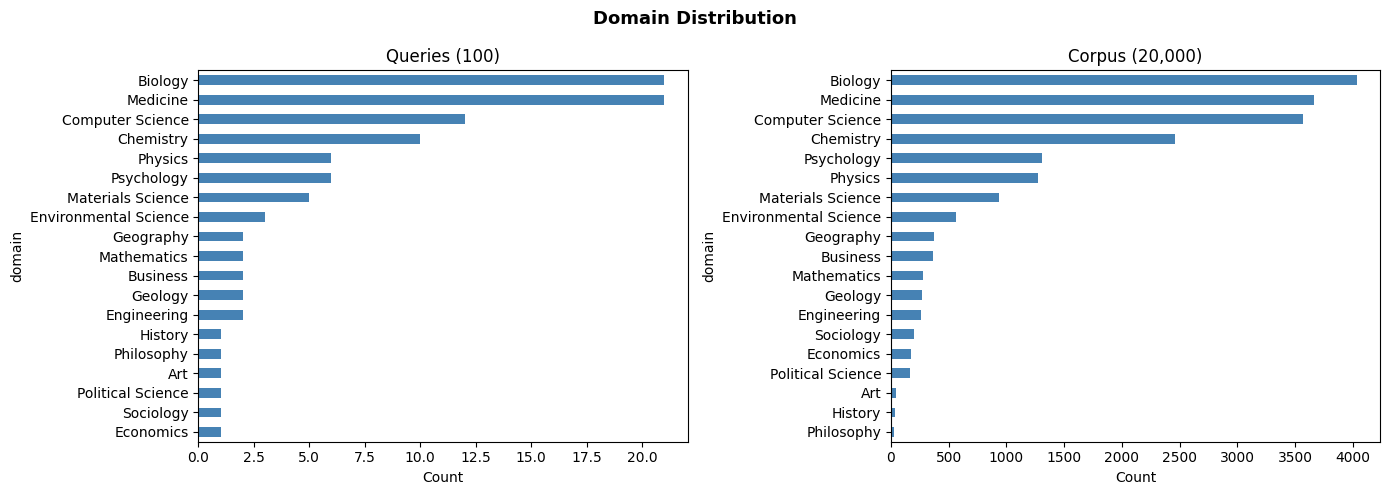

In [7]:
# Domain distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [
    (axes[0], queries, "Queries (100)"),
    (axes[1], corpus,  "Corpus (20,000)"),
]:
    counts = df["domain"].value_counts()
    counts.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.invert_yaxis()
plt.suptitle("Domain Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

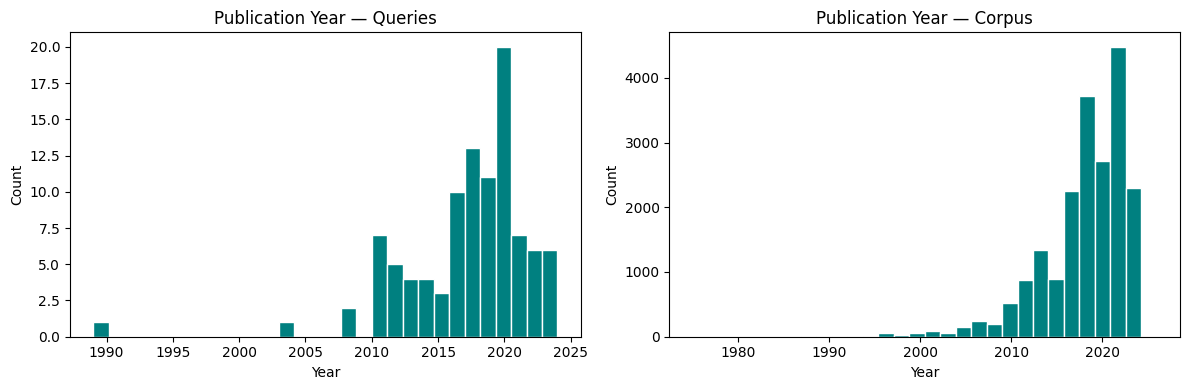

In [8]:
# Year distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in [
    (axes[0], queries, "Queries"),
    (axes[1], corpus,  "Corpus"),
]:
    years = df["year"].replace(0, np.nan).dropna()
    ax.hist(years, bins=30, color="teal", edgecolor="white")
    ax.set_title(f"Publication Year — {title}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 1.3 — Venue Statistics

Unique venues — corpus: 2,972   queries: 73


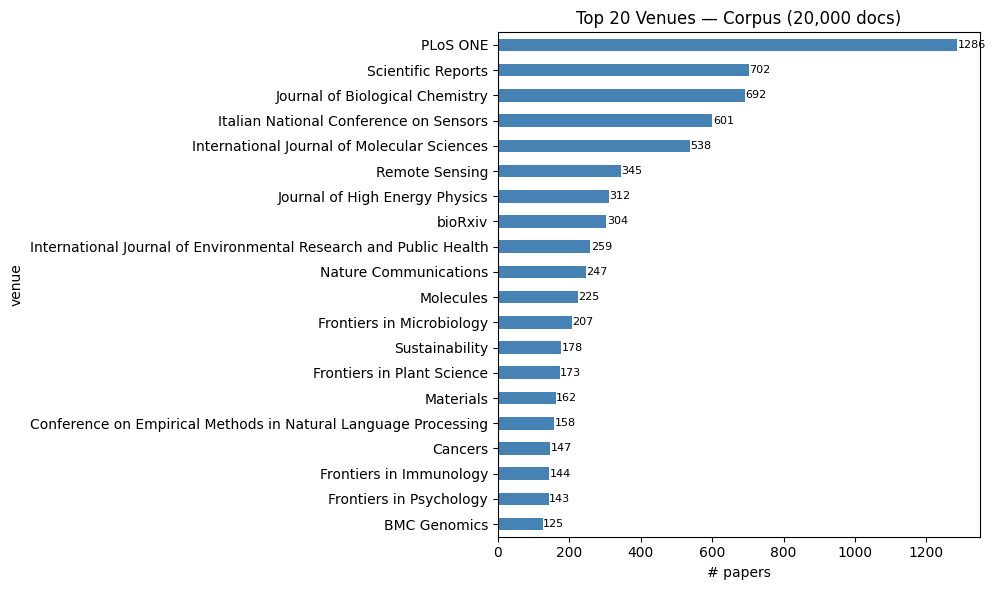


Top 3 venues per domain (5 largest domains):

  Biology:
     442  PLoS ONE
     309  Journal of Biological Chemistry
     169  International Journal of Molecular Sciences

  Medicine:
     241  PLoS ONE
     168  International Journal of Molecular Sciences
     108  Scientific Reports

  Computer Science:
     422  Italian National Conference on Sensors
     234  Remote Sensing
     157  Conference on Empirical Methods in Natural Language Processing

  Chemistry:
     299  Journal of Biological Chemistry
     155  PLoS ONE
     143  International Journal of Molecular Sciences

  Psychology:
     113  PLoS ONE
     100  Frontiers in Psychology
      68  International Journal of Environmental Research and Public Health


In [9]:


# Venue statistics
n_unique_corpus  = corpus["venue"].replace("", pd.NA).dropna().nunique()
n_unique_queries = queries["venue"].replace("", pd.NA).dropna().nunique()
print(f"Unique venues — corpus: {n_unique_corpus:,}   queries: {n_unique_queries:,}")

# Top 20 venues in corpus
top_venues = (
    corpus["venue"]
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_venues.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Venues — Corpus (20,000 docs)")
ax.set_xlabel("# papers")
ax.invert_yaxis()
for i, v in enumerate(top_venues):
    ax.text(v + 1, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Top venues per domain (top 3 venues for the 5 largest domains)
print("\nTop 3 venues per domain (5 largest domains):")
top5_domains = corpus["domain"].value_counts().head(5).index
for domain in top5_domains:
    top3 = (
        corpus[corpus["domain"] == domain]["venue"]
        .replace("", pd.NA).dropna()
        .value_counts().head(3)
    )
    print(f"\n  {domain}:")
    for venue, count in top3.items():
        print(f"    {count:>4}  {venue}")

### 1.2 — Citation & Relevance Stats

Gold docs per query:
  mean=7.36  median=3  min=2  max=71
  Queries with 1 gold  : 0
  Queries with 2–4     : 66
  Queries with 5+      : 34


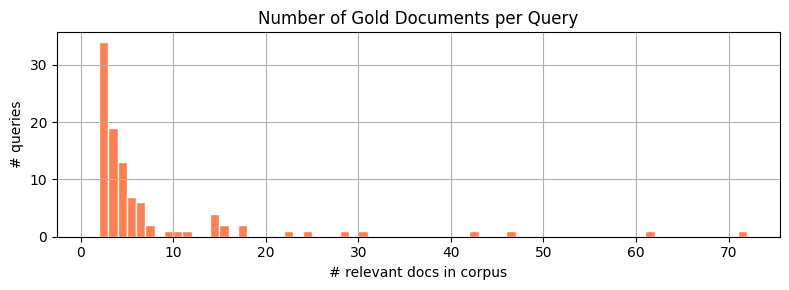

In [10]:
# Relevance distribution (how many gold docs per query?)
n_relevant = queries["n_relevant"]
print("Gold docs per query:")
print(f"  mean={n_relevant.mean():.2f}  median={n_relevant.median():.0f}  "
      f"min={n_relevant.min()}  max={n_relevant.max()}")
print(f"  Queries with 1 gold  : {(n_relevant == 1).sum()}")
print(f"  Queries with 2–4     : {((n_relevant >= 2) & (n_relevant <= 4)).sum()}")
print(f"  Queries with 5+      : {(n_relevant >= 5).sum()}")

fig, ax = plt.subplots(figsize=(8, 3))
n_relevant.hist(bins=range(1, n_relevant.max() + 2), ax=ax, color="coral", edgecolor="white")
ax.set_title("Number of Gold Documents per Query")
ax.set_xlabel("# relevant docs in corpus")
ax.set_ylabel("# queries")
plt.tight_layout()
plt.show()

In [11]:
# Verify all gold docs are present in corpus
corpus_id_set = set(corpus["doc_id"])
coverage = [
    sum(1 for d in docs if d in corpus_id_set) / len(docs)
    for docs in qrels.values() if docs
]
print(f"Average gold coverage in corpus : {np.mean(coverage):.1%}")
print(f"Queries with full coverage      : {sum(1 for c in coverage if c == 1.0)} / {len(coverage)}")

Average gold coverage in corpus : 100.0%
Queries with full coverage      : 100 / 100


### 1.3 — Title + Abstract Length Distribution

Queries TA length (chars):  mean=1524  median=1459  p5=663  p95=2344  max=3248
Corpus TA length (chars):  mean=1663  median=1592  p5=826  p95=2614  max=16514


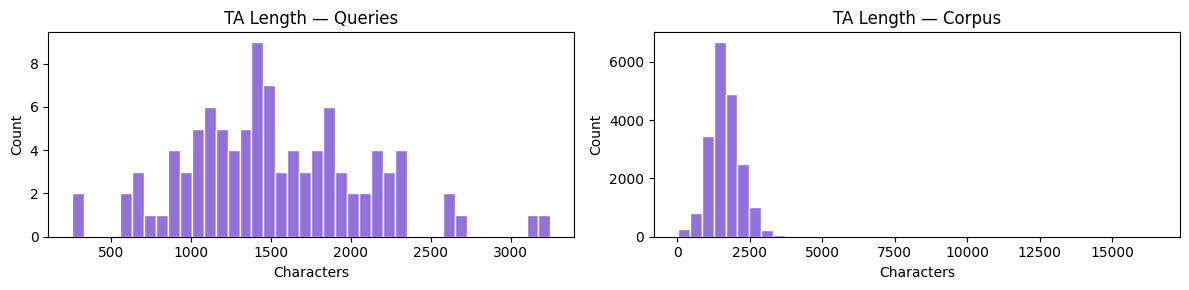

In [12]:
# TA length stats
for df, label in [(queries, "Queries"), (corpus, "Corpus")]:
    ta_len = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.len()
    print(f"{label} TA length (chars):  mean={ta_len.mean():.0f}  "
          f"median={ta_len.median():.0f}  p5={ta_len.quantile(0.05):.0f}  "
          f"p95={ta_len.quantile(0.95):.0f}  max={ta_len.max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, df, label in [(axes[0], queries, "Queries"), (axes[1], corpus, "Corpus")]:
    ta_len = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.len()
    ax.hist(ta_len, bins=40, color="mediumpurple", edgecolor="white")
    ax.set_title(f"TA Length — {label}")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 1.4 — Full-Text & Chunk Statistics

Each paper includes a `full_text` field (body text with paragraphs separated by `\n\n`) and a `chunk_meta` field encoding pre-computed section boundaries.  
Each entry has a `type` (`"ta"` or `"body"`) and a `char_start` offset into `full_text`.  
The `ta` entry additionally has `char_end`, so it can be sliced directly: `full_text[char_start:char_end]`.  
Body entries only have `char_start` — a section runs from its `char_start` to the next entry's `char_start` (or the end of `full_text` for the last section). The `get_chunks()` helper in Section 2 handles this automatically.

In [13]:
# Parse chunk_meta for all corpus docs
def parse_chunk_meta(cm_str):
    return json.loads(cm_str) if isinstance(cm_str, str) and cm_str else []

corpus_chunks = corpus["chunk_meta"].apply(parse_chunk_meta)
query_chunks  = queries["chunk_meta"].apply(parse_chunk_meta)

# Number of body chunks per paper (exclude the TA entry)
def n_body_chunks(meta):
    return sum(1 for e in meta if e.get("type") == "body")

corpus_n_body = corpus_chunks.apply(n_body_chunks)
query_n_body  = query_chunks.apply(n_body_chunks)

for label, s in [("Corpus", corpus_n_body), ("Queries", query_n_body)]:
    print(f"{label} body chunks/paper:  mean={s.mean():.1f}  "
          f"median={s.median():.0f}  min={s.min()}  max={s.max()}  "
          f"p5={s.quantile(0.05):.0f}  p95={s.quantile(0.95):.0f}")

Corpus body chunks/paper:  mean=10.8  median=9  min=2  max=156  p5=2  p95=24
Queries body chunks/paper:  mean=10.1  median=8  min=2  max=42  p5=2  p95=21


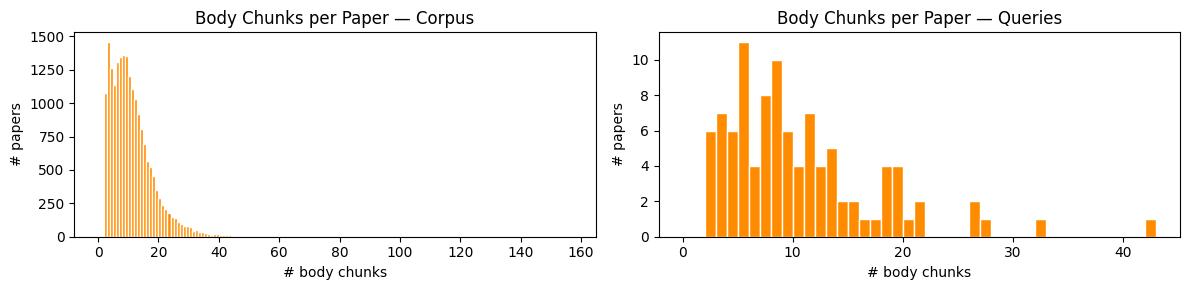

In [14]:
# Distribution of body chunk counts
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, s, label in [
    (axes[0], corpus_n_body, "Corpus"),
    (axes[1], query_n_body,  "Queries"),
]:
    ax.hist(s, bins=range(0, s.max() + 2), color="darkorange", edgecolor="white")
    ax.set_title(f"Body Chunks per Paper — {label}")
    ax.set_xlabel("# body chunks")
    ax.set_ylabel("# papers")
plt.tight_layout()
plt.show()

In [15]:
# Inspect chunks for a single paper
sample_row = corpus.iloc[0]
meta = parse_chunk_meta(sample_row["chunk_meta"])
full_text = sample_row["full_text"]

print(f"Paper: {sample_row['doc_id']}")
print(f"Title: {sample_row['title'][:80]}")
print(f"Total chunk entries: {len(meta)}  (1 TA + {len(meta)-1} body)\n")

for i, entry in enumerate(meta[:4]):   # show first 4 entries
    char_start = entry["char_start"]
    char_end   = entry.get("char_end") or (
        meta[i + 1]["char_start"] if i + 1 < len(meta) else len(full_text)
    )
    text = full_text[char_start:char_end].strip()
    print(f"[{i}] {entry['type'].upper()} chunk  chars {char_start}–{char_end}  ({char_end - char_start} chars)")
    print(f"    {text[:300]} ...")
    print()

Paper: f1c5e98774c4c7eb68496979cab2e57b8dcb2026
Title: Model-Observer Similarity, Error Modeling and Social Learning in Rhesus Macaques
Total chunk entries: 16  (1 TA + 15 body)

[0] TA chunk  chars 0–2033  (2033 chars)
    Model-Observer Similarity, Error Modeling and Social Learning in Rhesus Macaques

Monkeys readily learn to discriminate between rewarded and unrewarded items or actions by observing their conspecifics. However, they do not systematically learn from humans. Understanding what makes human-to-monkey tr ...

[1] BODY chunk  chars 8726–8876  (150 chars)
    Materials and Methods
The paragraphs below provide a brief description of the subjects and procedures. A more detailed account is available in [10]. ...

[2] BODY chunk  chars 8876–8946  (70 chars)
    Ethics
The study was carried out in strict accordance with Directive ...

[3] BODY chunk  chars 8946–9613  (667 chars)
    Enrichment
The animals housing quarters matched or exceeded the minimal surface, height, and vol

Corpus full_text length (chars): mean=39700  median=35956  p5=16622  p95=74762


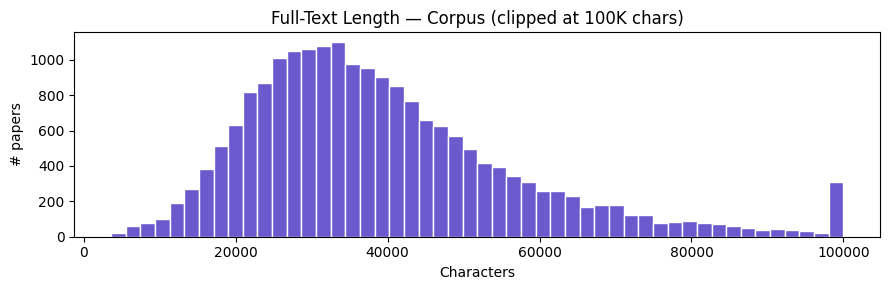

In [16]:
# Full-text length distribution (corpus)
ft_len = corpus["full_text"].str.len()
print(f"Corpus full_text length (chars): mean={ft_len.mean():.0f}  "
      f"median={ft_len.median():.0f}  p5={ft_len.quantile(0.05):.0f}  "
      f"p95={ft_len.quantile(0.95):.0f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(ft_len.clip(upper=100_000), bins=50, color="slateblue", edgecolor="white")
ax.set_title("Full-Text Length — Corpus (clipped at 100K chars)")
ax.set_xlabel("Characters")
ax.set_ylabel("# papers")
plt.tight_layout()
plt.show()

/tmp/ipykernel_8297/3589960137.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_domain, labels=domain_order, patch_artist=True,


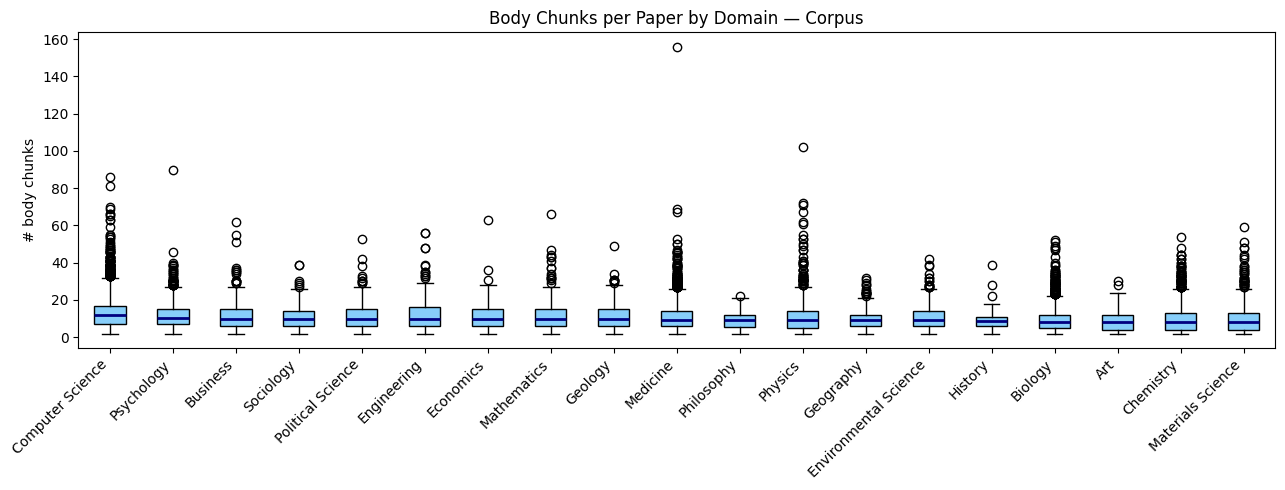


Domain                        Papers  Median chunks  Median section (chars)
---------------------------------------------------------------------------
Computer Science                3571             12                    1642
Psychology                      1306             10                    1583
Business                         363             10                    1782
Sociology                        196             10                    2212
Political Science                168             10                    1889
Engineering                      264             10                    1843
Economics                        173             10                    1967
Mathematics                      277             10                    1607
Geology                          273             10                    2086
Medicine                        3662              9                    1571
Philosophy                        27              9                    2910
Physics    

In [17]:
# Body chunks per paper broken down by domain
corpus["n_body_chunks"] = corpus["chunk_meta"].apply(
    lambda cm: sum(1 for e in json.loads(cm) if e.get("type") == "body")
)

domain_order = corpus.groupby("domain")["n_body_chunks"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
data_by_domain = [corpus[corpus["domain"] == d]["n_body_chunks"].values for d in domain_order]
ax.boxplot(data_by_domain, labels=domain_order, patch_artist=True,
           boxprops=dict(facecolor="lightskyblue"), medianprops=dict(color="navy", linewidth=2))
ax.set_title("Body Chunks per Paper by Domain — Corpus")
ax.set_ylabel("# body chunks")
ax.set_xticklabels(domain_order, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Median body chunks and section length per domain
print(f"\n{'Domain':<28}  {'Papers':>6}  {'Median chunks':>13}  {'Median section (chars)':>22}")
print("-" * 75)
for domain in domain_order:
    sub = corpus[corpus["domain"] == domain]
    med_chunks = sub["n_body_chunks"].median()
    section_lens = []
    for row in sub.itertuples():
        meta = json.loads(row.chunk_meta)
        body = [e for e in meta if e.get("type") == "body"]
        for j, e in enumerate(body):
            end = body[j + 1]["char_start"] if j + 1 < len(body) else len(row.full_text)
            section_lens.append(end - e["char_start"])
    med_sec = int(np.median(section_lens)) if section_lens else 0
    print(f"{domain:<28}  {len(sub):>6}  {med_chunks:>13.0f}  {med_sec:>22}")

---
## Section 2 — Helper Functions

All reusable utilities are defined here. **Run this cell before any retrieval section.**

In [18]:
# ════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS — run this block before any retrieval
# ════════════════════════════════════════════════════════════

import json, math, os
from pathlib import Path
import numpy as np
import pandas as pd

# ── Data loaders ────────────────────────────────────────────

def load_queries(path) -> pd.DataFrame:
    """Load queries.parquet → DataFrame with doc_id, title, abstract, ta, full_text, chunk_meta, domain, year, n_relevant."""
    return pd.read_parquet(path)


def load_corpus(path) -> pd.DataFrame:
    """Load corpus.parquet → DataFrame with doc_id, title, abstract, ta, full_text, chunk_meta, domain, year."""
    return pd.read_parquet(path)


def load_qrels(path) -> dict:
    """Load qrels.json → {query_id: [doc_id, ...]}"""
    with open(path) as f:
        return json.load(f)


def load_embeddings(emb_path, ids_path):
    """
    Load pre-computed embeddings and their corresponding IDs.
    Returns (embeddings: np.ndarray float32, ids: list).
    """
    embeddings = np.load(emb_path).astype(np.float32)
    with open(ids_path) as f:
        ids = json.load(f)
    assert len(embeddings) == len(ids), "Embedding count mismatch"
    return embeddings, ids


# ── Text formatting ──────────────────────────────────────────

def format_text(row) -> str:
    """Return title + abstract as a single string for retrieval."""
    title    = str(row.get("title", "") or "").strip()
    abstract = str(row.get("abstract", "") or "").strip()
    if title and abstract:
        return title + " " + abstract
    return title or abstract


# ── Chunk extraction ─────────────────────────────────────────

def get_chunks(full_text: str, chunk_meta_json) -> list:
    """
    Extract all text sections from a paper using pre-computed chunk metadata.

    Each chunk entry has char_start and (for body chunks) the end is inferred
    as the start of the next section, or the end of full_text for the last one.

    Args:
        full_text:       raw paper text (paragraphs separated by \\n\\n)
        chunk_meta_json: JSON string or list of chunk entries from chunk_meta

    Returns:
        list of dicts: [{"type": "ta"|"body", "text": str,
                         "char_start": int, "char_end": int}]
    """
    meta = json.loads(chunk_meta_json) if isinstance(chunk_meta_json, str) else chunk_meta_json
    chunks = []
    for i, entry in enumerate(meta):
        char_start = entry["char_start"]
        if entry["type"] == "ta":
            char_end = entry["char_end"]
        else:
            # Body section spans from char_start to the next section's start (or end of text)
            char_end = meta[i + 1]["char_start"] if i + 1 < len(meta) else len(full_text)
        text = full_text[char_start:char_end].strip()
        chunks.append({"type": entry["type"], "text": text,
                       "char_start": char_start, "char_end": char_end})
    return chunks


def get_ta(row) -> str:
    """Return the pre-extracted title+abstract string from a paper row."""
    return str(row.get("ta", "") or "").strip()


def get_body_chunks(row, min_chars: int = 100) -> list:
    """
    Return all body section texts for a paper row, filtering out very short sections.

    Args:
        row:       a DataFrame row with full_text and chunk_meta columns
        min_chars: minimum character length to keep a section (default 100)
    """
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    return [c["text"] for c in chunks
            if c["type"] == "body" and len(c["text"]) >= min_chars]


# ── Metric functions (per-query) ─────────────────────────────

def recall_at_k(ranked: list, relevant: set, k: int) -> float:
    """Fraction of relevant docs found in the top-k results."""
    if not relevant:
        return 0.0
    hits = sum(1 for doc in ranked[:k] if doc in relevant)
    return hits / len(relevant)


def precision_at_k(ranked: list, relevant: set, k: int) -> float:
    """Fraction of top-k results that are relevant."""
    if k == 0:
        return 0.0
    hits = sum(1 for doc in ranked[:k] if doc in relevant)
    return hits / k


def mrr_at_k(ranked: list, relevant: set, k: int) -> float:
    """Reciprocal rank of the first relevant document in top-k."""
    for rank, doc in enumerate(ranked[:k], start=1):
        if doc in relevant:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(ranked: list, relevant: set, k: int) -> float:
    """Normalized Discounted Cumulative Gain at k."""
    dcg = sum(
        1.0 / math.log2(rank + 1)
        for rank, doc in enumerate(ranked[:k], start=1)
        if doc in relevant
    )
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(r + 1) for r in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def average_precision(ranked: list, relevant: set) -> float:
    """Average Precision (area under the precision-recall curve) for one query."""
    if not relevant:
        return 0.0
    hits, score = 0, 0.0
    for rank, doc in enumerate(ranked, start=1):
        if doc in relevant:
            hits += 1
            score += hits / rank
    return score / len(relevant)


# ── Aggregate evaluation ─────────────────────────────────────

def evaluate(
    submission: dict,
    qrels: dict,
    ks: list = None,
    query_domains: dict = None,
    verbose: bool = True,
) -> dict:
    """
    Evaluate a retrieval submission.

    Args:
        submission:    {query_id: [top-100 doc_ids]}
        qrels:         {query_id: [relevant doc_ids]}
        ks:            cut-off values, default [10, 100]
        query_domains: {query_id: domain} — enables per-domain breakdown
        verbose:       print formatted results table

    Returns:
        dict with 'overall' metrics and optional 'per_domain'
    """
    if ks is None:
        ks = [10, 100]

    per_query = {}
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked   = submission.get(qid, [])
        q = {}
        for k in ks:
            q[f"Recall@{k}"]    = recall_at_k(ranked, relevant, k)
            q[f"Precision@{k}"] = precision_at_k(ranked, relevant, k)
            q[f"MRR@{k}"]       = mrr_at_k(ranked, relevant, k)
            q[f"NDCG@{k}"]      = ndcg_at_k(ranked, relevant, k)
        q["AP"] = average_precision(ranked, relevant)
        per_query[qid] = q

    metric_keys = list(next(iter(per_query.values())).keys()) if per_query else []
    overall = {}
    for key in metric_keys:
        vals = [per_query[qid][key] for qid in per_query]
        overall[key] = float(np.mean(vals))
    overall["MAP"] = overall.pop("AP", 0.0)
    overall["num_queries"] = len(per_query)

    result = {"overall": overall, "per_query": per_query}

    if query_domains:
        per_domain = {}
        for domain in sorted(set(query_domains.values())):
            dqids = [q for q in per_query if query_domains.get(q) == domain]
            if not dqids:
                continue
            dm = {}
            for key in metric_keys:
                dm[key] = float(np.mean([per_query[q][key] for q in dqids]))
            dm["MAP"] = dm.pop("AP", 0.0)
            dm["num_queries"] = len(dqids)
            per_domain[domain] = dm
        result["per_domain"] = per_domain

    if verbose:
        _print_results(result, ks)

    return result


def _print_results(results: dict, ks: list):
    o = results["overall"]
    print("\n" + "=" * 68)
    print("OVERALL RESULTS")
    print("=" * 68)
    for label, keys in [
        ("Recall",    [f"Recall@{k}"    for k in ks]),
        ("Precision", [f"Precision@{k}" for k in ks]),
        ("MRR",       [f"MRR@{k}"       for k in ks]),
        ("NDCG",      [f"NDCG@{k}"      for k in ks]),
    ]:
        row = f"{label:<14}"
        for k, key in zip(ks, keys):
            row += f"  @{k:>3}: {o.get(key, 0):.4f}"
        print(row)
    print(f"{'MAP':<14}  {o.get('MAP', 0):.4f}")
    print(f"{'Queries':<14}  {int(o.get('num_queries', 0))}")

    if "per_domain" in results:
        print("\n" + "-" * 68)
        print("PER-DOMAIN  (first k only)")
        print("-" * 68)
        k = ks[0]
        print(f"  {'Domain':<28} R@{k:<3} P@{k:<3} MRR@{k:<3} NDCG@{k:<3}  MAP    n")
        for domain, dm in sorted(results["per_domain"].items()):
            print(
                f"  {domain:<28}"
                f" {dm.get(f'Recall@{k}', 0):.3f}"
                f" {dm.get(f'Precision@{k}', 0):.3f}"
                f" {dm.get(f'MRR@{k}', 0):.3f}  "
                f" {dm.get(f'NDCG@{k}', 0):.3f}"
                f"  {dm.get('MAP', 0):.3f}"
                f"  {int(dm.get('num_queries', 0))}"
            )
    print()

# list of body text strings, one per document in the corpus
def get_body_texts(corpus_df, min_chars=100):
    body_texts = []
    for _, row in corpus_df.iterrows():
        chunks = get_chunks(row["full_text"], row["chunk_meta"])
        body_texts.append(
            " ".join(
                chunk["text"]
                for chunk in chunks
                if chunk["type"] == "body" and len(chunk["text"]) >= min_chars
            )
        )
    return body_texts


# used before score interpolation in Section 7, to make sparse and dense scores on the same scale before combining them
def normalize_score_rows(score_matrix):
    row_min = score_matrix.min(axis=1, keepdims=True)
    row_max = score_matrix.max(axis=1, keepdims=True)
    denom = np.where(row_max > row_min, row_max - row_min, 1.0)
    return (score_matrix - row_min) / denom

# compute BM25 scores between all queries and all documents using the vectorized CountVectorizer approach
def bm25_score_matrix(doc_counts, query_counts, k1=1.2, b=0.7):
    n_docs = doc_counts.shape[0]
    df = np.asarray((doc_counts > 0).sum(axis=0)).ravel().astype(np.float64)
    idf = np.log1p((n_docs - df + 0.5) / (df + 0.5))

    doc_lengths = np.asarray(doc_counts.sum(axis=1)).ravel().astype(np.float64)
    avgdl = max(doc_lengths.mean(), 1.0)

    tf = doc_counts.tocsr().copy().astype(np.float64)
    row_ids = np.repeat(np.arange(n_docs), np.diff(tf.indptr))
    tf.data = tf.data * (k1 + 1.0) / (
        tf.data + k1 * (1.0 - b + b * doc_lengths[row_ids] / avgdl)
    )

    weighted_docs = tf @ sp.diags(idf)
    return (query_counts.tocsr().astype(np.float64) @ weighted_docs.T).toarray()

# find top-k document indices per query, sorted by score and faster than a full sort
def _top_k_indices(score_matrix, top_k):
    candidate_idx = np.argpartition(-score_matrix, kth=top_k - 1, axis=1)[:, :top_k]
    candidate_scores = np.take_along_axis(score_matrix, candidate_idx, axis=1)
    order = np.argsort(-candidate_scores, axis=1)
    return np.take_along_axis(candidate_idx, order, axis=1)

# convert a raw score matrix into a submission dictionary
def scores_to_submission(score_matrix, corpus_ids, query_ids, top_k=100):
    top_indices = _top_k_indices(score_matrix, top_k)
    return {
        qid: [corpus_ids[j] for j in top_indices[i]]
        for i, qid in enumerate(query_ids)
    }


def bm25_retrieve_from_counts(
    doc_counts,
    query_counts,
    corpus_ids,
    query_ids,
    k1=1.2,
    b=0.7,
    top_k=100,
):
    scores = bm25_score_matrix(doc_counts, query_counts, k1=k1, b=b)
    return scores_to_submission(scores, corpus_ids, query_ids, top_k=top_k)

# merge multiple ranked lists into one using RRF.
def rrf_fuse(submissions, query_ids, k=60, top_k=100):
    fused = {}
    for qid in query_ids:
        scores = {}
        for submission in submissions:
            docs = submission.get(qid, [])
            for rank, doc_id in enumerate(docs, start=1):
                scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
        fused[qid] = [
            doc_id
            for doc_id, _ in sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        ]
    return fused

print("Helper functions loaded.")

Helper functions loaded.


---
## Section 3 — TF-IDF Baseline

A simple sparse retrieval baseline using TF-IDF cosine similarity over **title + abstract** only.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load data (re-load in case this section is run independently)
DATA_DIR = Path('/content/drive/My Drive/challenge/data')
# DATA_DIR = Path('../data')
queries = load_queries(DATA_DIR / "queries.parquet")
# for submission
# queries = load_queries(DATA_DIR / "../held_out_queries.parquet")
corpus  = load_corpus(DATA_DIR / "corpus.parquet")
qrels   = load_qrels(DATA_DIR / "qrels.json")

query_ids  = queries["doc_id"].tolist()
corpus_ids = corpus["doc_id"].tolist()

# Use title + abstract for retrieval (TA only)
query_texts  = [format_text(row) for _, row in queries.iterrows()]
corpus_texts = [format_text(row) for _, row in corpus.iterrows()]

print(f"Queries : {len(query_texts)}")
print(f"Corpus  : {len(corpus_texts)}")

Queries : 100
Corpus  : 20000


In [20]:
# Build TF-IDF index on corpus TA
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 1),
    stop_words="english",
)
corpus_matrix = vectorizer.fit_transform(corpus_texts)   # (20000, vocab)
query_matrix  = vectorizer.transform(query_texts)        # (100, vocab)
print(f"Corpus matrix : {corpus_matrix.shape}  vocab={corpus_matrix.shape[1]:,}")
print(f"Query  matrix : {query_matrix.shape}")

Corpus matrix : (20000, 44105)  vocab=44,105
Query  matrix : (100, 44105)


In [21]:
# Retrieve top-100 per query
TOP_K = 100
sim_matrix = cosine_similarity(query_matrix, corpus_matrix)   # (100, 20000)

tfidf_submission = {}
for i, qid in enumerate(query_ids):
    top_indices = np.argsort(-sim_matrix[i])[:TOP_K]
    tfidf_submission[qid] = [corpus_ids[j] for j in top_indices]

print(f"Submission: {len(tfidf_submission)} queries × {TOP_K} results")

Submission: 100 queries × 100 results


In [22]:
# Evaluate
query_domains = dict(zip(queries["doc_id"], queries["domain"]))
tfidf_results = evaluate(tfidf_submission, qrels, ks=[10, 100],
                         query_domains=query_domains, verbose=True)


OVERALL RESULTS
Recall          @ 10: 0.4445  @100: 0.7512
Precision       @ 10: 0.2270  @100: 0.0528
MRR             @ 10: 0.6655  @100: 0.6713
NDCG            @ 10: 0.4841  @100: 0.5594
MAP             0.3804
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   MAP    n
  Art                          0.500 0.200 1.000   0.508  0.306  1
  Biology                      0.415 0.205 0.664   0.436  0.324  21
  Business                     0.500 0.350 0.750   0.562  0.456  2
  Chemistry                    0.404 0.360 0.770   0.551  0.383  10
  Computer Science             0.267 0.242 0.526   0.396  0.318  12
  Economics                    0.294 0.500 1.000   0.633  0.424  1
  Engineering                  0.250 0.100 0.583   0.265  0.175  2
  Environmental Science        0.624 0.433 0.778   0.667  0.

In [23]:
# ── TODO 2 ───────────────────────────────────────────────────────────────────
# Pick any query and inspect its top-5 TF-IDF results.
selected_qid = query_ids[0]
top_docs = tfidf_submission[selected_qid][:5]
gold_docs = set(qrels.get(selected_qid, []))
query_row = queries[queries["doc_id"] == selected_qid].iloc[0]
print("Query title: "+ query_row["title"])
# For each retrieved document, print its title and whether it is a gold doc.
print("\nTop-5 retrieved documents:\n")
for rank, doc_id in enumerate(top_docs, start=1):
    doc_row = corpus[corpus["doc_id"] == doc_id].iloc[0]
    is_gold = doc_id in gold_docs

    print(f"{rank}. [{doc_id}] {doc_row['title']}")
    print(f"    Gold: {'Gold Doc' if is_gold else 'Not Gold Doc'}\n")
#
# Hint: tfidf_submission[qid] gives the ranked list of doc IDs for that query.
#       qrels[qid] gives the set of gold doc IDs.
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE

Query title: Ecotypic Morphological and Physio-Biochemical Responses of Two Differentially Adapted Forage Grasses, Cenchrus ciliaris L. and Cyperus arenarius Retz. to Drought Stress

Top-5 retrieved documents:

1. [5330446c9ce825a30a2203f662cea725009e7e7b] Plant growth promoting rhizobacteria alleviates drought stress in potato in response to suppressive oxidative stress and antioxidant enzymes activities
    Gold: Not Gold Doc

2. [c929c327882ddae690e808e55771227930933b53] Comparative physiological and biochemical mechanisms of salt tolerance in five contrasting highland quinoa cultivars
    Gold: Gold Doc

3. [a93d7533e0ca8f778c218a1f5a489228e2d8042c] Differential Morphophysiological, Biochemical, and Molecular Responses of Maize Hybrids to Salinity and Alkalinity Stresses
    Gold: Not Gold Doc

4. [298f411bdcc0a8ee016c415b519789ce847c8b1c] Effects of salinity and drought on growth, ionic relations, compatible solutes and activation of antioxidant systems in oleander (Nerium oleande

In [24]:
# Save submission
os.makedirs("../submissions", exist_ok=True)
with open("../submissions/submission_data.json", "w") as f:
    json.dump(tfidf_submission, f)
print("Saved → ../submissions/submission_data.json")

Saved → ../submissions/submission_data.json


---
## Section 4 — Dense Retrieval Baseline

Dense retrieval using pre-computed embeddings from [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) (22M params).  
Texts were encoded as `title + " " + abstract`. Embeddings are L2-normalised → cosine similarity = dot product.  
To re-encode with a different model, run `scripts/embed.py --model <model-name>`.

In [25]:
EMB_DIR = DATA_DIR / "embeddings" / "sentence-transformers_all-MiniLM-L6-v2"

for f in ["query_embeddings.npy", "corpus_embeddings.npy",
          "query_ids.json", "corpus_ids.json", "model_info.txt"]:
    path = EMB_DIR / f
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {status}  {path}")

if (EMB_DIR / "model_info.txt").exists():
    print("\nModel info:")
    print((EMB_DIR / "model_info.txt").read_text())

  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/query_embeddings.npy
  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/corpus_embeddings.npy
  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/query_ids.json
  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/corpus_ids.json
  ✓  /content/drive/My Drive/challenge/data/embeddings/sentence-transformers_all-MiniLM-L6-v2/model_info.txt

Model info:
model: sentence-transformers/all-MiniLM-L6-v2
embedding_dim: 384
normalize_embeddings: True
text_format: title + ' ' + abstract



In [26]:
# Load embeddings
query_embs, q_ids = load_embeddings(EMB_DIR / "query_embeddings.npy",
                                     EMB_DIR / "query_ids.json")
corpus_embs, c_ids = load_embeddings(EMB_DIR / "corpus_embeddings.npy",
                                      EMB_DIR / "corpus_ids.json")
print(f"Query  embeddings : {query_embs.shape}")
print(f"Corpus embeddings : {corpus_embs.shape}")

Query  embeddings : (100, 384)
Corpus embeddings : (20000, 384)


In [27]:
# Dense retrieval
TOP_K = 100

# ── TODO 3 ───────────────────────────────────────────────────────────────────
# Compute the cosine similarity matrix between all queries and all corpus docs.
# The embeddings are already L2-normalised, so cosine similarity = dot product.
# sim_matrix should have shape (n_queries, n_corpus).
#
# Hint: use matrix multiplication between query_embs and corpus_embs.
# ─────────────────────────────────────────────────────────────────────────────
# YOUR CODE HERE
sim_matrix = np.dot(query_embs, corpus_embs.T)
top_indices = np.argsort(-sim_matrix, axis=1)[:, :TOP_K]
dense_submission = {qid: [c_ids[j] for j in top_indices[i]]
                    for i, qid in enumerate(q_ids)}
print(f"Submission: {len(dense_submission)} queries × {TOP_K} results")

Submission: 100 queries × 100 results


In [28]:
# Evaluate
dense_results = evaluate(dense_submission, qrels, ks=[10, 100],
                         query_domains=query_domains, verbose=True)


OVERALL RESULTS
Recall          @ 10: 0.4716  @100: 0.8104
Precision       @ 10: 0.2440  @100: 0.0587
MRR             @ 10: 0.6812  @100: 0.6834
NDCG            @ 10: 0.5073  @100: 0.5903
MAP             0.4080
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   MAP    n
  Art                          0.500 0.200 1.000   0.586  0.417  1
  Biology                      0.459 0.214 0.734   0.471  0.362  21
  Business                     0.400 0.400 0.562   0.471  0.415  2
  Chemistry                    0.333 0.330 0.682   0.473  0.320  10
  Computer Science             0.323 0.300 0.549   0.447  0.374  12
  Economics                    0.412 0.700 1.000   0.792  0.539  1
  Engineering                  0.250 0.100 0.750   0.318  0.230  2
  Environmental Science        0.557 0.400 0.548   0.522  0.

In [29]:
# Summary comparison
comparison = []
for name, res in [("TF-IDF", tfidf_results), ("all-MiniLM-L6-v2", dense_results)]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison.append(row)
pd.DataFrame(comparison).set_index("Model")

,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
all-MiniLM-L6-v2,0.4716,0.2440,0.6812,0.5073,0.8104,0.0587,0.6834,0.5903,0.4080


In [30]:
# Save dense submission
with open("../submissions/dense_minilm.json", "w") as f:
    json.dump(dense_submission, f)
print("Saved → ../submissions/dense_minilm.json")

Saved → ../submissions/dense_minilm.json


---
## What's Next?

You now have two baselines over title + abstract. The data also exposes `full_text` and `chunk_meta` for more advanced retrieval.

### Sparse retrieval improvements
- **BM25**: tune `k1` and `b` parameters; typically outperforms TF-IDF on recall.
- **Full-text BM25**: index body chunks instead of TA — use `get_body_chunks(row)` from the helpers.

### Dense retrieval improvements
- **Domain-specific models**: try `allenai/specter2_base` (trained on scientific citations).
- **Chunk-level encoding**: encode each body chunk separately, aggregate scores per document (max or mean pooling).
- **Re-encode**: `scripts/embed.py --model <model-name>` generates fresh embedding files.

### Hybrid retrieval
- **Reciprocal Rank Fusion (RRF)**: combine ranked lists without score normalisation.
  ```python
  # RRF score for doc d = Σ_i  1 / (60 + rank_i(d))
  ```
- **Score interpolation**: `α * sparse_score + (1-α) * dense_score` after per-retriever normalisation.

### Reranking
- **Cross-encoder reranker**: rerank the top-100 results from a first-stage retriever.
- **Paragraph-level reranking**: score each body chunk independently, aggregate to document level.

Submit your best system as `{query_id: [top-100 doc_ids]}`.

---
# Section 5 - Sparse Retrieval Improvements (BM25)

Implement BM25 (one time using BM25Okapi in part-1, and then using CountVectorizer in part-2) on text + abstract then on full-text using default values of parameters (k1, b), and fine tune k1&b in both cases, evaluate, show best parameters with best scores, compare all results with TF-IDF results and discuss the scores.

## 5.1 Sparse retrieval improvements - 1

### 5.1.1. BM25 TA: implement BM25, use BM25Okapi.

Implementing the BM25 on text+abstract ranking algorithm to retrieve relevant documents. The corpus is preprocessed through tokenization, where each document is converted into lowercase word tokens (with punctuation removed). These tokenized documents are then indexed using the BM25Okapi model, configured with standard hyperparameters for term frequency scaling and document length normalization(k1=1.5, b=0.75). For each query, the same tokenization process is applied, and BM25 relevance scores are computed against all documents in the corpus. Documents are subsequently ranked according to their scores, and the top 100 highest-ranked results are selected for each query. The retrieved doc-ids are stored in a submission structure for evaluation that we did at the end and show the results.


In [ ]:
!pip install rank_bm25

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from rank_bm25 import BM25Okapi
import re

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

ta_corpus_tokens = [
    tokenize(text)
    for text in corpus_texts
]

bm25_ta = BM25Okapi(ta_corpus_tokens, k1=1.5, b=0.75)
ta_submission = {}

for i, q in enumerate(query_texts):
    scores = bm25_ta.get_scores(tokenize(q))
    top_idx = np.argsort(scores)[::-1][:100]
    ta_submission[query_ids[i]] = [corpus_ids[j] for j in top_idx]
print("\n****************************** BM25 (TA) Results ******************************")
bm25_results = evaluate(ta_submission, qrels, verbose=True)


****************************** BM25 (TA) Results ******************************

OVERALL RESULTS
Recall          @ 10: 0.4285  @100: 0.6865
Precision       @ 10: 0.2180  @100: 0.0468
MRR             @ 10: 0.6492  @100: 0.6525
NDCG            @ 10: 0.4639  @100: 0.5189
MAP             0.3464
Queries         100



### 5.1.2. BM25 TA: Tune k1 and b parameters

Performing hyperparameter tuning for the BM25 (TA) by testing multiple combinations of the parameters k1 and b to improve search performance. For each combination, a new BM25 model is built using the tokenized corpus. Each query is then processed to compute BM25 relevance scores, rank all documents, retrieve the top 100 results, and track the best performing parameter pair based on the highest recall@100 score. The retrieved rankings are evaluated against qrels and print results and best performing parameters pair.


In [ ]:
# tuneing
print("\n****************************** BM25 (TA) Results After Tuning k,b ******************************")

k1_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
b_values  = [0.2, 0.3, 0.5, 0.7]

best_score = -1
best_results = None
best_params = None
best_submission = None

for k1 in k1_values:
    for b in b_values:
        bm25 = BM25Okapi(ta_corpus_tokens, k1=k1, b=b)
        submission = {}
        for i, q in enumerate(query_texts):
            scores = bm25.get_scores(tokenize(q))
            top_idx = np.argsort(scores)[::-1][:100]
            submission[query_ids[i]] = [corpus_ids[j] for j in top_idx]

        results = evaluate(submission, qrels, verbose=False)
        recall = results["overall"]["Recall@100"]

        print(f"k1={k1}, b={b} → Recall@100={recall:.4f}")

        if recall > best_score:
           best_score = recall
           best_results = results
           best_params = (k1, b)
           best_submission = submission

best_results = evaluate(best_submission, qrels, verbose=False)

print("\n****************************** BEST BM25 (TA) Results ******************************")
print(f"Best k1 = {best_params[0]}, b = {best_params[1]}")
print(f"Best Recall@100 = {best_score:.4f}")
for k, v in best_results["overall"].items():
    if k != "num_queries":
        print(f"{k}: {v:.4f}")


****************************** BM25 (TA) Results After Tuning k,b ******************************
k1=0.8, b=0.2 → Recall@100=0.6268
k1=0.8, b=0.3 → Recall@100=0.6399
k1=0.8, b=0.5 → Recall@100=0.6646
k1=0.8, b=0.7 → Recall@100=0.6775
k1=1.0, b=0.2 → Recall@100=0.6203
k1=1.0, b=0.3 → Recall@100=0.6345
k1=1.0, b=0.5 → Recall@100=0.6641
k1=1.0, b=0.7 → Recall@100=0.6871
k1=1.2, b=0.2 → Recall@100=0.6119
k1=1.2, b=0.3 → Recall@100=0.6331
k1=1.2, b=0.5 → Recall@100=0.6641
k1=1.2, b=0.7 → Recall@100=0.6746
k1=1.5, b=0.2 → Recall@100=0.6074
k1=1.5, b=0.3 → Recall@100=0.6198
k1=1.5, b=0.5 → Recall@100=0.6543
k1=1.5, b=0.7 → Recall@100=0.6778
k1=1.8, b=0.2 → Recall@100=0.5999
k1=1.8, b=0.3 → Recall@100=0.6160
k1=1.8, b=0.5 → Recall@100=0.6470
k1=1.8, b=0.7 → Recall@100=0.6794
k1=2.0, b=0.2 → Recall@100=0.5960
k1=2.0, b=0.3 → Recall@100=0.6107
k1=2.0, b=0.5 → Recall@100=0.6371
k1=2.0, b=0.7 → Recall@100=0.6841

****************************** BEST BM25 (TA) Results ******************************


### 5.1.3. BM25 Full-text: index body chunks instead of TA

Implementing BM25 on the full text to retrieve relevant documents. The corpus was first preprocessed through tokenization, where each document's body content was combined into a single text string, converted into lowercase word tokens, and dropped punctuation. These tokenized full-text documents were then indexed using the BM25Okapi model with standard hyperparameter settings (k1 = 1.5, b = 0.75). For each query, the same tokenization process was applied, and BM25 relevance scores were computed against all documents in the corpus. Documents were ranked according to their scores, and the top 100 highest-ranked results were selected for each query. The retrieved document IDs were stored in a submission structure and evaluated to print results.


In [ ]:
full_corpus_tokens = [
    tokenize(" ".join(get_body_chunks(row)))
    for _, row in corpus.iterrows()
]

bm25_full = BM25Okapi(full_corpus_tokens, k1=1.5, b=0.75)
full_submission = {}

for i, q in enumerate(query_texts):
    scores = bm25_full.get_scores(tokenize(q))
    top_idx = np.argsort(scores)[::-1][:100]
    full_submission[query_ids[i]] = [corpus_ids[j] for j in top_idx]
print("\n****************************** BM25 (Full Text) Results ******************************")
full_results = evaluate(full_submission, qrels, verbose=True)


****************************** BM25 (Full Text) Results ******************************

OVERALL RESULTS
Recall          @ 10: 0.4365  @100: 0.7168
Precision       @ 10: 0.2300  @100: 0.0531
MRR             @ 10: 0.6918  @100: 0.6975
NDCG            @ 10: 0.4979  @100: 0.5628
MAP             0.3974
Queries         100



### 5.1.4. BM25 Full-text: tuning k1 and b1

Performing hyperparameter tuning for the BM25 on the full text to improve performance. We did grid search over different values of the BM25 parameters k1 and b. For each parameter combination, a new BM25 model is trained on the full corpus, and relevance scores are computed for all queries using the same tokenization process. Documents are then ranked based on their BM25 scores, and the top 100 results are selected for each query. The retrieval output is stored in a submission structure and evaluated to print results, we choose the best-performing parameter setting based on highest recall@100 and print the best combination.


In [ ]:
# tuneing
k1_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
b_values  = [0.2, 0.3, 0.5, 0.7]

best_score = -1
best_params = None
best_full_results = None
best_full_submission = None

for k1 in k1_values:
    for b in b_values:
        bm25 = BM25Okapi(full_corpus_tokens, k1=k1, b=b)

        submission = {}
        for i, q in enumerate(query_texts):
            scores = bm25.get_scores(tokenize(q))
            top_idx = np.argsort(scores)[::-1][:100]
            submission[query_ids[i]] = [corpus_ids[j] for j in top_idx]

        results = evaluate(submission, qrels, verbose=False)
        recall = results["overall"]["Recall@100"]

        print(f"k1={k1}, b={b} → Recall@100={recall:.4f}")

        if recall > best_score:
            best_score = recall
            best_params = (k1, b)
            best_full_results = results
            best_full_submission = submission

print("\n****************************** BM25 (Full Text) Tuned Results ******************************")
print(f"Best k1 = {best_params[0]}, b = {best_params[1]}")
print(f"Best Recall@100 = {best_score:.4f}")
for k, v in best_full_results["overall"].items():
    if k != "num_queries":
        print(f"{k}: {v:.4f}")

k1=0.8, b=0.2 → Recall@100=0.6432
k1=0.8, b=0.3 → Recall@100=0.6497
k1=0.8, b=0.5 → Recall@100=0.6602
k1=0.8, b=0.7 → Recall@100=0.6855
k1=1.0, b=0.2 → Recall@100=0.6401
k1=1.0, b=0.3 → Recall@100=0.6511
k1=1.0, b=0.5 → Recall@100=0.6670
k1=1.0, b=0.7 → Recall@100=0.6925
k1=1.2, b=0.2 → Recall@100=0.6395
k1=1.2, b=0.3 → Recall@100=0.6544
k1=1.2, b=0.5 → Recall@100=0.6741
k1=1.2, b=0.7 → Recall@100=0.6952
k1=1.5, b=0.2 → Recall@100=0.6432
k1=1.5, b=0.3 → Recall@100=0.6547
k1=1.5, b=0.5 → Recall@100=0.6755
k1=1.5, b=0.7 → Recall@100=0.7123
k1=1.8, b=0.2 → Recall@100=0.6416
k1=1.8, b=0.3 → Recall@100=0.6484
k1=1.8, b=0.5 → Recall@100=0.6754
k1=1.8, b=0.7 → Recall@100=0.7141
k1=2.0, b=0.2 → Recall@100=0.6415
k1=2.0, b=0.3 → Recall@100=0.6543
k1=2.0, b=0.5 → Recall@100=0.6744
k1=2.0, b=0.7 → Recall@100=0.7146

****************************** BM25 (Full Text) Tuned Results ******************************
Best k1 = 2.0, b = 0.7
Best Recall@100 = 0.7146
Recall@10: 0.4448
Precision@10: 0.2330
MRR

### 5.1.5. Compare BM25 vs TF-IDF Results

,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
BM25 (TA Default),0.4285,0.2180,0.6492,0.4639,0.6865,0.0468,0.6525,0.5189,0.3464
BM25 (TA Tuned),0.4105,0.2100,0.6467,0.4516,0.6871,0.0465,0.6507,0.5125,0.3385
BM25 (Full Default),0.4365,0.2300,0.6918,0.4979,0.7168,0.0531,0.6975,0.5628,0.3974
BM25 (Full Tuned),0.4448,0.2330,0.7013,0.5037,0.7146,0.0530,0.7064,0.5639,0.3987


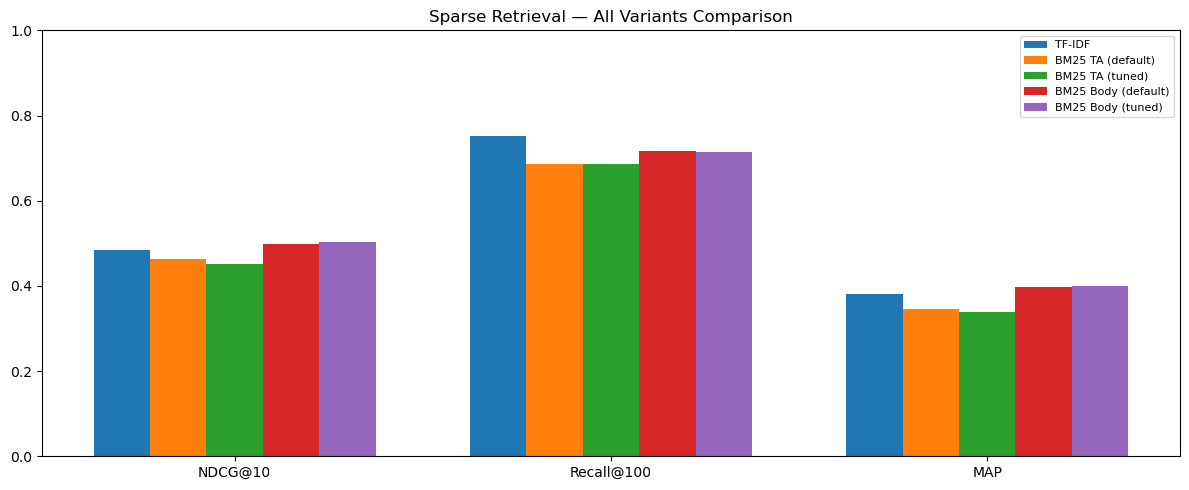

In [ ]:
comparison = []

for name, res in [
    ("TF-IDF", tfidf_results),
    ("BM25 (TA Default)", bm25_results),
    ("BM25 (TA Tuned)", best_results),
    ("BM25 (Full Default)", full_results),
    ("BM25 (Full Tuned)", best_full_results)
]:
    row = {"Model": name}
    row.update({
        k: f"{v:.4f}"
        for k, v in res["overall"].items()
        if k != "num_queries"
    })
    comparison.append(row)

display(pd.DataFrame(comparison).set_index("Model"))
# plot
models = ["TF-IDF", "BM25 TA (default)", "BM25 TA (tuned)",
          "BM25 Body (default)", "BM25 Body (tuned)"]
results_list = [tfidf_results, bm25_results, best_results,
                full_results, best_full_results]
metrics = ["NDCG@10", "Recall@100", "MAP"]

x = np.arange(len(metrics))
width = 0.15
fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, res) in enumerate(zip(models, results_list)):
    vals = [res["overall"][m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=model)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title("Sparse Retrieval — All Variants Comparison")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.1.6. Results discussion

We notice that BM25 with full-text representation performs best, especially after tuning, achieving the highest scores across most metrics. This shows that using the complete document content improves retrieval effectiveness compared to using only text + abstract. BM25 generally outperforms TF-IDF because of better handling of term frequency and document length normalization.

Full-text performs better than text+abstract, indicating that richer document context improves ranking quality. Parameter tuning improved full-text BM25 scores, while tuning in case of BM25 TA affect negatively on its scores(reduced the score of BM25 TA), maybe BM25 more sensitive to document length and benefits more from tuning when applied to longer documents.

So BM25 Full Tuned is the best performing model.

## 5.2. Sparse retrieval improvements - 2

### 5.2.1. BM25 TA: implement BM25, use CountVectorizer.

Implementing BM25 (TA) corpus using a bag-of-words representation. The corpus is first preprocessed using a CountVectorizer, where documents are converted into sparse term-frequency vectors after removing stopwords and filtering rare and overly frequent terms. The resulting document-term matrix is used to compute BM25 relevance scores directly in a vectorized form. Queries are transformed using the same vocabulary, and BM25 scores are calculated between each query and all documents. Documents are then ranked according to their scores, and the top 100 results are retrieved for each query. The retrieved doc-ids are stored in a submission structure and evaluated to show results.

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
import scipy.sparse as sp

ta_vectorizer = CountVectorizer(min_df=2, max_df=0.95, stop_words="english")
ta_corpus_counts = ta_vectorizer.fit_transform(corpus_texts)
ta_query_counts = ta_vectorizer.transform(query_texts)

bm25_ta_submission = bm25_retrieve_from_counts(
    ta_corpus_counts,
    ta_query_counts,
    corpus_ids,
    query_ids,
    k1=1.5,
    b=0.75,
    top_k=100,
)

print("\n****************************** BM25 (TA) Results ******************************")
print({"vocab_size": len(ta_vectorizer.vocabulary_), "k1": 1.5, "b": 0.75})
bm25_ta_results = evaluate(bm25_ta_submission, qrels, verbose=True)


****************************** BM25 (TA) Results ******************************
{'vocab_size': 44105, 'k1': 1.5, 'b': 0.75}

OVERALL RESULTS
Recall          @ 10: 0.4186  @100: 0.7154
Precision       @ 10: 0.2190  @100: 0.0502
MRR             @ 10: 0.6360  @100: 0.6399
NDCG            @ 10: 0.4555  @100: 0.5247
MAP             0.3473
Queries         100



### 5.2.2. BM25 TA: tune k1 & b.

Performing hyperparameter tuning of the BM25 retrieval model on the text+abstract (TA) using a bag-of-words representation. The model is evaluated over different combinations of the BM25 parameters k1 & b. For each combination, BM25 retrieval is applied to rank documents for all queries, and the top 100 results are generated per query. The system performance is evaluated, combined score of evaluation metrics is used to select the optimal parameter configuration and select the best-performing model. Show evaluation results for each pair of parameters and the best one

In [32]:
# tuning
k1_values = [1.2, 1.5, 1.8]
b_values = [0.5, 0.75, 0.9]

best_score = -1
best_results = None
best_params = None
best_ta_submission = None

for k1 in k1_values:
    for b in b_values:
        submission = bm25_retrieve_from_counts(
            ta_corpus_counts,
            ta_query_counts,
            corpus_ids,
            query_ids,
            k1=k1,
            b=b,
            top_k=100,
        )
        results = evaluate(submission, qrels, verbose=False)
        combined = results["overall"]["Recall@100"] + results["overall"]["NDCG@10"] + results["overall"]["MAP"]

        print(
            f'k1={k1}, b={b} -> Recall@100={results["overall"]["Recall@100"]:.4f}  '
            f'NDCG@10={results["overall"]["NDCG@10"]:.4f}  MAP={results["overall"]["MAP"]:.4f}'
        )

        if combined > best_score:
            best_score = combined
            best_results = results
            best_params = {"k1": k1, "b": b}
            best_ta_submission = submission

bm25_tuned_results = best_results
bm25_tuned_submission = best_ta_submission
print("\n****************************** BM25 (TA) Results After Tuning k1 & b ******************************")
print("\nBest TA parameters:", best_params)
for k, v in best_results["overall"].items():
    if k != "num_queries":
        print(f"{k}: {v:.4f}")

k1=1.2, b=0.5 -> Recall@100=0.7041  NDCG@10=0.4517  MAP=0.3452
k1=1.2, b=0.75 -> Recall@100=0.7127  NDCG@10=0.4603  MAP=0.3490
k1=1.2, b=0.9 -> Recall@100=0.7192  NDCG@10=0.4659  MAP=0.3547
k1=1.5, b=0.5 -> Recall@100=0.7092  NDCG@10=0.4471  MAP=0.3434
k1=1.5, b=0.75 -> Recall@100=0.7154  NDCG@10=0.4555  MAP=0.3473
k1=1.5, b=0.9 -> Recall@100=0.7216  NDCG@10=0.4607  MAP=0.3536
k1=1.8, b=0.5 -> Recall@100=0.7088  NDCG@10=0.4441  MAP=0.3420
k1=1.8, b=0.75 -> Recall@100=0.7143  NDCG@10=0.4546  MAP=0.3473
k1=1.8, b=0.9 -> Recall@100=0.7251  NDCG@10=0.4630  MAP=0.3561

****************************** BM25 (TA) Results After Tuning k1 & b ******************************

Best TA parameters: {'k1': 1.8, 'b': 0.9}
Recall@10: 0.4257
Precision@10: 0.2210
MRR@10: 0.6430
NDCG@10: 0.4630
Recall@100: 0.7251
Precision@100: 0.0507
MRR@100: 0.6470
NDCG@100: 0.5333
MAP: 0.3561


### 5.2.3. BM25 full-text: index body chunks instead of TA.

Implement BM25 on body-text corpus using a vectorized bag-of-words representation. Document body texts are first extracted from the corpus with a minimum length threshold to remove very short content. The processed texts are then transformed into sparse term-frequency vectors using a CountVectorizer with stopword removal and document-frequency filtering. Queries are converted using the same vocabulary, and BM25 relevance scores are computed through a score matrix using optimized parameter settings (k1 = 1.2, b = 0.7). Documents are ranked according to their BM25 scores, and the top 100 results are retrieved for each query. The ranked doc-ids are stored in a submission structure and evaluated against qrels. Printing scores at the end.


In [33]:
body_texts = get_body_texts(corpus, min_chars=100)
body_vectorizer = CountVectorizer(min_df=2, max_df=0.95, stop_words="english")
body_corpus_counts = body_vectorizer.fit_transform(body_texts)
body_query_counts = body_vectorizer.transform(query_texts)

full_default_scores = bm25_score_matrix(body_corpus_counts, body_query_counts, k1=1.2, b=0.7)
bm25_body_submission = scores_to_submission(full_default_scores, corpus_ids, query_ids, top_k=100)
full_meta = {
    "min_chars": 100,
    "min_df": 2,
    "max_df": 0.95,
    "k1": 1.2,
    "b": 0.7,
    "top_k": 100,
    "vocab_size": len(body_vectorizer.vocabulary_),
}

print("\n****************************** BM25 (Body Text) Results ******************************")
print(full_meta)
bm25_full_results = evaluate(bm25_body_submission, qrels, verbose=True)


****************************** BM25 (Body Text) Results ******************************
{'min_chars': 100, 'min_df': 2, 'max_df': 0.95, 'k1': 1.2, 'b': 0.7, 'top_k': 100, 'vocab_size': 214897}

OVERALL RESULTS
Recall          @ 10: 0.4353  @100: 0.7678
Precision       @ 10: 0.2330  @100: 0.0554
MRR             @ 10: 0.6696  @100: 0.6763
NDCG            @ 10: 0.4843  @100: 0.5629
MAP             0.3837
Queries         100



### 5.2.4. BM25 Full-text: tune k1 & b

Perform hyperparameter tuning of the BM25 on the body-text corpus using a vectorized term-frequency representation. Multiple combinations of the BM25 parameters k1 and b are tested to optimize ranking scores. For each parameter setting, BM25 relevance scores are computed between queries and documents, and the top 100 ranked documents are retrieved for every query. Model performance is evaluated. A combined score based on evaluation metrics is used to identify the best-performing parameter configuration. Show best parameters pair and best scores.


In [34]:
# tunuing
body_k1_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
body_b_values = [0.3, 0.5, 0.7, 0.9]

body_runs = []
best_body_score = -1
best_body_params = None
bm25_full_tuned_results = None
bm25_best_body_submission = None
best_body_scores = None

for k1 in body_k1_values:
    for b in body_b_values:
        score_matrix = bm25_score_matrix(body_corpus_counts, body_query_counts, k1=k1, b=b)
        submission = scores_to_submission(score_matrix, corpus_ids, query_ids, top_k=100)
        results = evaluate(submission, qrels, verbose=False)
        combined = results["overall"]["Recall@100"] + results["overall"]["NDCG@10"] + results["overall"]["MAP"]
        body_runs.append({
            "k1": k1,
            "b": b,
            "Recall@100": results["overall"]["Recall@100"],
            "NDCG@10": results["overall"]["NDCG@10"],
            "MAP": results["overall"]["MAP"],
            "combined": combined,
        })
        print(
            f'k1={k1}, b={b} -> Recall@100={results["overall"]["Recall@100"]:.4f}  '
            f'NDCG@10={results["overall"]["NDCG@10"]:.4f}  MAP={results["overall"]["MAP"]:.4f}'
        )
        if combined > best_body_score:
            best_body_score = combined
            best_body_params = {"k1": k1, "b": b}
            bm25_full_tuned_results = results
            bm25_best_body_submission = submission
            best_body_scores = score_matrix
print("\n****************************** BM25 (Body Text) Tuned ******************************")
print("\nBest body parameters:", best_body_params)
pd.DataFrame(body_runs).sort_values("combined", ascending=False)

k1=0.8, b=0.3 -> Recall@100=0.6983  NDCG@10=0.4546  MAP=0.3563
k1=0.8, b=0.5 -> Recall@100=0.7245  NDCG@10=0.4686  MAP=0.3690
k1=0.8, b=0.7 -> Recall@100=0.7464  NDCG@10=0.4768  MAP=0.3777
k1=0.8, b=0.9 -> Recall@100=0.7676  NDCG@10=0.4854  MAP=0.3854
k1=1.0, b=0.3 -> Recall@100=0.7130  NDCG@10=0.4599  MAP=0.3615
k1=1.0, b=0.5 -> Recall@100=0.7389  NDCG@10=0.4712  MAP=0.3749
k1=1.0, b=0.7 -> Recall@100=0.7594  NDCG@10=0.4786  MAP=0.3802
k1=1.0, b=0.9 -> Recall@100=0.7730  NDCG@10=0.4902  MAP=0.3923
k1=1.2, b=0.3 -> Recall@100=0.7245  NDCG@10=0.4647  MAP=0.3642
k1=1.2, b=0.5 -> Recall@100=0.7529  NDCG@10=0.4723  MAP=0.3748
k1=1.2, b=0.7 -> Recall@100=0.7678  NDCG@10=0.4843  MAP=0.3837
k1=1.2, b=0.9 -> Recall@100=0.7729  NDCG@10=0.4945  MAP=0.4000
k1=1.5, b=0.3 -> Recall@100=0.7289  NDCG@10=0.4663  MAP=0.3679
k1=1.5, b=0.5 -> Recall@100=0.7596  NDCG@10=0.4766  MAP=0.3780
k1=1.5, b=0.7 -> Recall@100=0.7707  NDCG@10=0.4958  MAP=0.3970
k1=1.5, b=0.9 -> Recall@100=0.7902  NDCG@10=0.5053  MAP

,k1,b,Recall@100,NDCG@10,MAP,combined
23,2.0,0.9,0.796118,0.517116,0.417077,1.730311
19,1.8,0.9,0.791476,0.516774,0.414647,1.722897
15,1.5,0.9,0.790245,0.505252,0.406081,1.701578
22,2.0,0.7,0.785747,0.497020,0.403707,1.686475
18,1.8,0.7,0.785414,0.496717,0.400961,1.683092
11,1.2,0.9,0.772914,0.494523,0.400011,1.667448
14,1.5,0.7,0.770659,0.495828,0.397024,1.663511
7,1.0,0.9,0.773011,0.490191,0.392292,1.655494
21,2.0,0.5,0.767619,0.486318,0.387596,1.641533
3,0.8,0.9,0.767583,0.485410,0.385367,1.638360


### 5.2.5. Compare BM25 with TF-IDF Results

,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
BM25 (TA Default),0.4186,0.2190,0.6360,0.4555,0.7154,0.0502,0.6399,0.5247,0.3473
BM25 (TA Tuned),0.4257,0.2210,0.6430,0.4630,0.7251,0.0507,0.6470,0.5333,0.3561
BM25 (Full Default),0.4353,0.2330,0.6696,0.4843,0.7678,0.0554,0.6763,0.5629,0.3837
BM25 (Full Tuned),0.4643,0.2450,0.7126,0.5171,0.7961,0.0572,0.7212,0.5985,0.4171


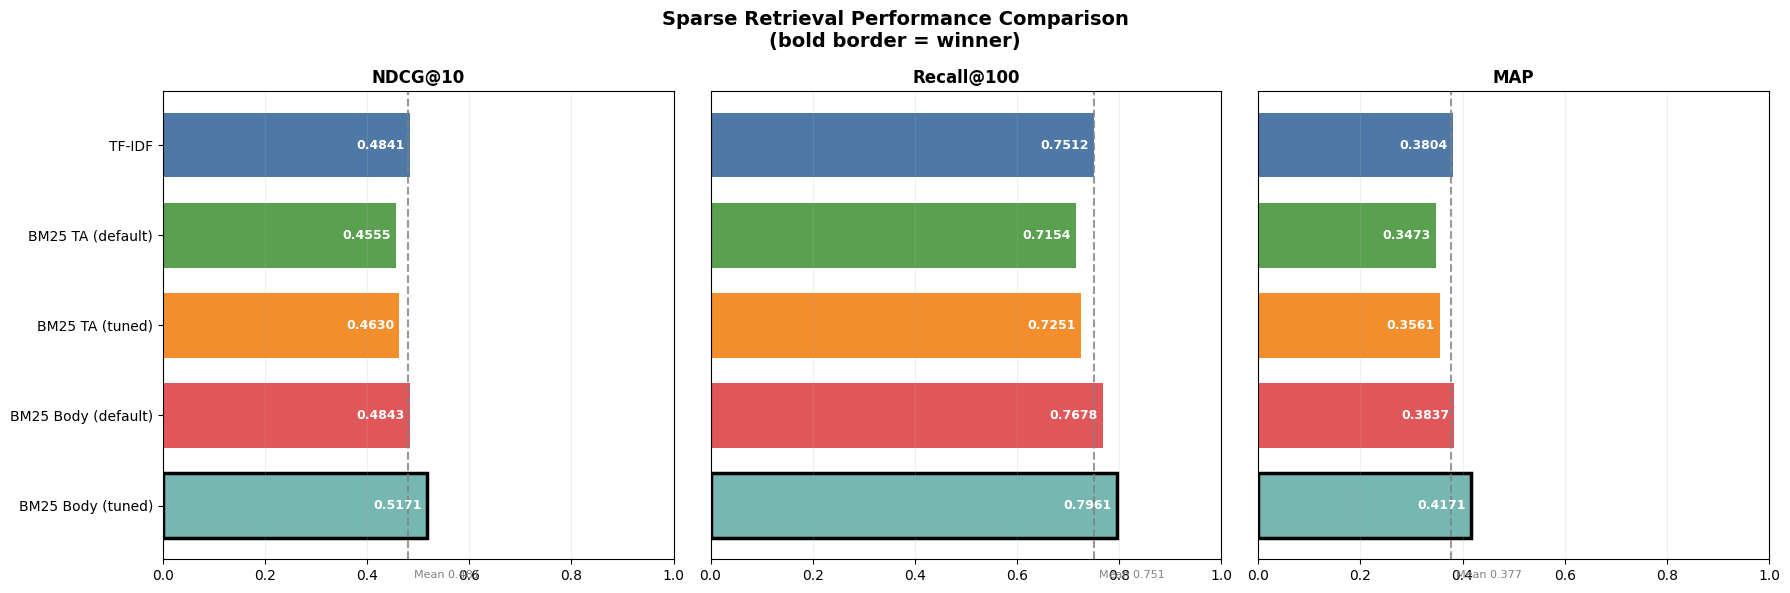

In [35]:
comparison = []

for name, res in [
    ("TF-IDF", tfidf_results),
    ("BM25 (TA Default)", bm25_ta_results),
    ("BM25 (TA Tuned)", bm25_tuned_results),
    ("BM25 (Full Default)", bm25_full_results),
    ("BM25 (Full Tuned)", bm25_full_tuned_results)
]:
    row = {"Model": name}
    row.update({
        k: f"{v:.4f}"
        for k, v in res["overall"].items()
        if k != "num_queries"
    })
    comparison.append(row)

df = pd.DataFrame(comparison).set_index("Model")
display(df)
# plot
models = [
    "TF-IDF",
    "BM25 TA (default)",
    "BM25 TA (tuned)",
    "BM25 Body (default)",
    "BM25 Body (tuned)"
]

results_list = [
    tfidf_results,
    bm25_ta_results,
    bm25_tuned_results,
    bm25_full_results,
    bm25_full_tuned_results
]

metrics = ["NDCG@10", "Recall@100", "MAP"]

colors = ["#4E79A7", "#59A14F", "#F28E2B", "#E15759", "#76B7B2"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

y = np.arange(len(models))

for ax, metric in zip(axes, metrics):

    scores = [res["overall"][metric] for res in results_list]

    winner = np.argmax(scores)
    mean_score = np.mean(scores)

    bars = ax.barh(y, scores, color=colors, height=0.72)

    bars[winner].set_edgecolor("black")
    bars[winner].set_linewidth(2.5)

    for i, bar in enumerate(bars):
        ax.text(
            bar.get_width() - 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{scores[i]:.4f}",
            ha="right",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold"
        )

    ax.axvline(mean_score, linestyle="--", color="gray", alpha=0.8)

    ax.text(mean_score + 0.01, len(models)-0.2,
            f"Mean {mean_score:.3f}",
            fontsize=8, color="gray")

    ax.set_title(metric, fontweight="bold")
    ax.grid(axis="x", alpha=0.2)
    ax.set_xlim(0, 1)
axes[0].set_yticks(y)
axes[0].set_yticklabels(models)
axes[0].invert_yaxis()

for ax in axes[1:]:
    ax.tick_params(left=False)

fig.suptitle("Sparse Retrieval Performance Comparison\n(bold border = winner)",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### 5.2.6. Results discussion

The results show that BM25 (Full Tuned) is the best-performing model, achieving the highest scores across all evaluation metrics, so combining full-text document representation with parameter tuning significantly improves scores. It is better than text+abstract models, maybe because richer document content provides more useful context for ranking relevant documents. Both BM25 (full-text) models outperform BM25 TA models and TF-IDF.

BM25 (TA Tuned) improves over BM25 (TA Default), TF-IDF remains a strong baseline and performs better than BM25 TA.

In comparison with the results in part-1 (BM25Okapi), we notice that the CountVectorizer-based implementation achieves higher scores, suggesting that the vectorized representation is more effective for this dataset.

Overall, document representation quality and parameter tuning are both important factors, and BM25 (Full Tuned) providing the strongest retrieval performance.



---
# Section 6 - Dense Retrieval Improvements
Dense retrieval using the domain-specific allenai/specter2_base model (trained on scientific citations) with a proximity adapter. Additionally, chunk-level encoding is applied by scoring each body chunk independently and aggregating to document level via max/mean pooling. Results are compared and discussed against the Section 4 MiniLM baseline.

## 6.1. Dense retrieval improvements

### 6.1.1. Domain-specific models: try allenai/specter2_base (trained on scientific citations).

Implement dense retrieval system using the SPECTER2 transformer model. The pretrained model allenai/specter2_base is loaded together with the proximity adapter to improve semantic similarity matching between queries and documents. Input texts are tokenized using the corresponding tokenizer with padding, truncation, and a maximum sequence length of 512 tokens. The model processes texts in batches efficient encoding. For each input text, the contextual embedding of the [CLS] token is extracted as the document representation and normalized to unit length for cosine similarity comparison. The resulting dense embeddings are stored as numerical vectors.

Applying the SPECTER2 dense model to the text+abstract (TA) representation of the query and corpus documents. Query and corpus texts are first constructed by combining the required textual fields into formatted inputs. These texts are then encoded into dense semantic embeddings using the pretrained SPECTER2 model with the proximity adapter. The encoding process is performed in batches for efficiency, producing fixed-length vector representations for both queries and corpus documents. Computing cosine similarity through matrix multiplication between query and document embeddings. Documents are ranked according to similarity scores, and the top 100 most relevant documents are selected for each query. The ranked doc-ids are stored in a submission structure and evaluated.

In [ ]:
!pip install adapters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 115.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
import sys
from pathlib import Path
from tqdm.auto import tqdm
sys.path.append(str(Path("../scripts").resolve()))
import torch
from adapters import AutoAdapterModel
from transformers import AutoTokenizer
from huggingface_hub import snapshot_download
from tqdm.auto import tqdm
import numpy as np

CHUNK_MODEL = "allenai/specter2_base"
POOLING     = "max"
TOP_K       = 100
BATCH_SIZE  = 128
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

adapter_local_path = "../data/specter2_proximity_adapter"
if not Path(adapter_local_path).exists():
    print("Downloading adapter...")
    snapshot_download(
        "allenai/specter2",
        local_dir=adapter_local_path,
        local_dir_use_symlinks=False,
    )
    print("Done.")

tokenizer     = AutoTokenizer.from_pretrained("allenai/specter2_base")
specter_model = AutoAdapterModel.from_pretrained("allenai/specter2_base")
specter_model.load_adapter(adapter_local_path, load_as="proximity", set_active=True)
specter_model.eval().to(DEVICE)
print(f"Model loaded on {DEVICE}")

def encode_texts(texts, batch_size=BATCH_SIZE, desc="Encoding"):
    all_embs = []
    for start in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[start : start + batch_size]
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=512, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = specter_model(**enc)
        emb = out.last_hidden_state[:, 0, :]
        emb = emb / emb.norm(dim=-1, keepdim=True)
        all_embs.append(emb.cpu().float().numpy())
    return np.vstack(all_embs)

query_texts_ta  = [format_text(row) for _, row in tqdm(queries.iterrows(),
                   total=len(queries), desc="Building query texts")]
specter_c_texts = [format_text(row) for _, row in tqdm(corpus.iterrows(),
                   total=len(corpus), desc="Building corpus texts")]

specter_q_embs = encode_texts(query_texts_ta, desc="Encoding queries (specter TA)")
specter_c_embs = encode_texts(specter_c_texts, desc="Encoding corpus (specter TA)")

print(f"Query  embeddings: {specter_q_embs.shape}")
print(f"Corpus embeddings: {specter_c_embs.shape}")

sim_specter        = specter_q_embs @ specter_c_embs.T
specter_q_ids      = queries["doc_id"].tolist()
specter_c_ids      = corpus["doc_id"].tolist()
specter_submission = scores_to_submission(sim_specter, specter_c_ids, specter_q_ids, top_k=100)
print(f"****************************** Specter2 Results ****************************** ")
specter_results = evaluate(specter_submission, qrels, ks=[10, 100],
                           query_domains=query_domains, verbose=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Building query texts:   0%|          | 0/100 [00:00<?, ?it/s]

Building corpus texts:   0%|          | 0/20000 [00:00<?, ?it/s]

Encoding queries (specter TA):   0%|          | 0/1 [00:00<?, ?it/s]

Encoding corpus (specter TA):   0%|          | 0/157 [00:00<?, ?it/s]

Query  embeddings: (100, 768)
Corpus embeddings: (20000, 768)
****************************** Specter2 Results ****************************** 

OVERALL RESULTS
Recall          @ 10: 0.4712  @100: 0.7819
Precision       @ 10: 0.2490  @100: 0.0570
MRR             @ 10: 0.6432  @100: 0.6501
NDCG            @ 10: 0.4973  @100: 0.5714
MAP             0.3946
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   MAP    n
  Art                          0.250 0.100 0.250   0.168  0.087  1
  Biology                      0.475 0.233 0.670   0.471  0.356  21
  Business                     0.400 0.400 0.667   0.516  0.426  2
  Chemistry                    0.394 0.330 0.664   0.498  0.338  10
  Computer Science             0.255 0.292 0.508   0.413  0.331  12
  Economics                    0.471 0.800 1.000   0

#### 6.1.1.1. Results Discussion

 * SPECTER2 achieves NDCG@10 = 0.4973, the MiniLM baseline (0.5073) is slightly better, suggesting that domain specialisation alone does not guarantee better retrieval on this dataset.

 * Per-domain:
    * **Strong domains**: History (1.0), Geology (0.719), Environmental Science (0.760); well-defined scientific fields where citation-based training helps
    * **Weak domains**: Geography (0.056 NDCG@10), Philosophy (0.0), Art (0.168), humanities and interdisciplinary fields are underrepresented in SPECTER2's citation training data.
    * We surprised that **Computer Science** (0.413) is weak for a model trained on academic papers

 * SPECTER2 was trained on citation relationships, not direct query-document relevance, citation proximity ≠ relevance to a query
MiniLM, though smaller and general-purpose, was fine-tuned on MS-MARCO which teaches direct relevance matching.
 * We think that SPECTER2 will likely contribute more as a complementary signal in fusion rather than a standalone retriever

In [ ]:
# Run this on terminal
# python scripts/embed.py --model allenai/specter2_base

### 6.1.2. Chunk-level encoding: encode each body chunk separately, aggregate scores per document (max or mean pooling).

Implement chunk-level dense retrieval system using the SPECTER2 model on full-text. Query texts are encoded into dense embeddings using the pretrained transformer model. Each corpus document is then divided into multiple body-text chunks, allowing long documents to be represented as smaller semantic units. If no body chunks are available, a fallback formatted document text is used. All chunks are encoded into dense vector representations in batches for computational efficiency. Compute similarity scores between query embeddings and all chunk embeddings. These chunk-level similarities are then aggregated into document-level relevance scores using either maximum pooling or mean pooling, where max pooling selects the most relevant chunk per document. Final document rankings are generated from the aggregated scores, and the top 100 results are retrieved for each query. Evaluate the system and show results.

In [ ]:
import scipy.sparse as sp

q_ids_list     = queries["doc_id"].tolist()
query_texts_ta = [format_text(row) for _, row in queries.iterrows()]

q_embs = encode_texts(query_texts_ta, desc="Encoding queries")
print(f"Query embeddings: {q_embs.shape}")

c_ids_list        = corpus["doc_id"].tolist()
c_id_to_idx       = {cid: i for i, cid in enumerate(c_ids_list)}
chunk_doc_indices = []
chunk_texts       = []

for _, row in tqdm(corpus.iterrows(), total=len(corpus), desc="Extracting chunks"):
    chunks  = get_body_chunks(row, min_chars=100)
    if not chunks:
        chunks = [format_text(row)]
    doc_idx = c_id_to_idx[row["doc_id"]]
    for text in chunks:
        chunk_doc_indices.append(doc_idx)
        chunk_texts.append(text)

chunk_doc_indices = np.array(chunk_doc_indices, dtype=np.int32)
n_docs, n_chunks  = len(c_ids_list), len(chunk_texts)
print(f"Chunks: {n_chunks:,} across {n_docs:,} docs  (avg {n_chunks/n_docs:.1f}/doc)")

chunk_embs = encode_texts(chunk_texts, desc="Encoding chunks")
print(f"Chunk embeddings: {chunk_embs.shape}")

sim_chunk = q_embs @ chunk_embs.T

n_queries  = len(q_ids_list)
doc_scores = np.full((n_queries, n_docs), -np.inf if POOLING == "max" else 0.0,
                     dtype=np.float32)

if POOLING == "mean":
    C      = sp.csr_matrix((np.ones(n_chunks, dtype=np.float32),
                             (chunk_doc_indices, np.arange(n_chunks))),
                            shape=(n_docs, n_chunks))
    counts = np.asarray(C.sum(axis=1)).ravel()
    doc_scores = (sim_chunk @ C.T.toarray())
    doc_scores /= np.where(counts > 0, counts, 1.0)[np.newaxis, :]

else:
    order      = np.argsort(chunk_doc_indices, kind="stable")
    sorted_idx = chunk_doc_indices[order]
    sim_sorted = sim_chunk[:, order]
    split_pts  = np.searchsorted(sorted_idx, np.arange(n_docs + 1))

    for doc_idx in tqdm(range(n_docs), desc="Max-pooling"):
        s, e = split_pts[doc_idx], split_pts[doc_idx + 1]
        if s < e:
            doc_scores[:, doc_idx] = sim_sorted[:, s:e].max(axis=1)

chunk_submission = scores_to_submission(doc_scores, c_ids_list, q_ids_list, top_k=TOP_K)

print(f"\n****************************** Chunk-level dense ({CHUNK_MODEL}, {POOLING}-pooling) ****************************** ")
chunk_results = evaluate(chunk_submission, qrels, ks=[10, 100],
                         query_domains=query_domains, verbose=True)


Encoding queries:   0%|          | 0/1 [00:00<?, ?it/s]

Query embeddings: (100, 768)


Extracting chunks:   0%|          | 0/20000 [00:00<?, ?it/s]

Chunks: 213,756 across 20,000 docs  (avg 10.7/doc)


Encoding chunks:   0%|          | 0/1670 [00:00<?, ?it/s]

### 6.1.3. Compare Dense Results

In [ ]:
comparison_rows = []
for name, res in [
    ("all-MiniLM-L6-v2 (TA)",                    dense_results),
    ("specter2_base (TA)",                         specter_results),
    (f"specter2_base (chunk, {POOLING}-pool)",     chunk_results),
]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items()
                if k != "num_queries"})
    comparison_rows.append(row)

pd.DataFrame(comparison_rows).set_index("Model")
models  = ["MiniLM (TA)", "SPECTER2 (TA)", f"SPECTER2 (chunk, {POOLING}-pool)"]
results_list = [dense_results, specter_results, chunk_results]
metrics = ["NDCG@10", "Recall@100", "MAP"]

x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, (model, res) in enumerate(zip(models, results_list)):
    vals = [res["overall"][m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=model)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title("Dense Retrieval Model Comparison")
ax.legend()
plt.tight_layout()
plt.show()


### 6.1.4. Results Discussion

---
# Section 7 - Hybrid Retrieval & Reranking

Combines sparse and dense ranked lists using Reciprocal Rank Fusion (RRF) and score interpolation (α × sparse + (1−α) × dense) after per-retriever normalisation. The best hybrid output is then reranked using a cross-encoder (MS-MARCO MiniLM) at both document level and paragraph level, with results compared across all hybrid and reranking variants.

## 7.1. Hybrid retrieval

### 7.1.1. Reciprocal Rank Fusion (RRF): combine ranked lists without score normalisation.

Apply RRF to combine multiple retrieval systems and improve overall ranking performance. Several fusion configurations are evaluated by merging the ranked outputs of tuned BM25 on text+abstract, tuned BM25 on body text, and dense retrieval models. For every configuration, the top 100 fused results are generated and evaluated. The performance of each fusion setting is compared, and the best configuration is selected based on the combined value of evaluation metrics.

In [ ]:
# merge multiple ranked lists into one using RRF.
def rrf_fuse(submissions, query_ids, k=60, top_k=100):
    fused = {}
    for qid in query_ids:
        scores = {}
        for submission in submissions:
            docs = submission.get(qid, [])
            for rank, doc_id in enumerate(docs, start=1):
                scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
        fused[qid] = [
            doc_id
            for doc_id, _ in sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        ]
    return fused

rrf_configs = {
    "RRF: TA-BM25 + Dense":            [bm25_tuned_submission, dense_submission],
    "RRF: Body-BM25 + Dense":          [best_body_submission, dense_submission],
    "RRF: TA-BM25 + Body-BM25":        [bm25_tuned_submission, best_body_submission],
    "RRF: TA-BM25 + Body-BM25 + Dense":[bm25_tuned_submission, best_body_submission, dense_submission],
}

rrf_results = {}
for name, submissions in rrf_configs.items():
    sub  = rrf_fuse(submissions, query_ids=query_ids, k=60, top_k=100)
    res  = evaluate(sub, qrels, ks=[10, 100], query_domains=query_domains, verbose=False)
    rrf_results[name] = (sub, res)
    print(f"{name}\n"
          f"  NDCG@10={res['overall']['NDCG@10']:.4f}  "
          f"Recall@100={res['overall']['Recall@100']:.4f}  "
          f"MAP={res['overall']['MAP']:.4f}\n")

best_rrf_name = max(rrf_results,
    key=lambda n: (rrf_results[n][1]['overall']['NDCG@10']
                 + rrf_results[n][1]['overall']['Recall@100']
                 + rrf_results[n][1]['overall']['MAP']))
best_rrf_submission, best_rrf_results = rrf_results[best_rrf_name]
print(f"Best RRF config: {best_rrf_name}")
evaluate(best_rrf_submission, qrels, ks=[10, 100], query_domains=query_domains, verbose=True)

### 7.1.2. Score interpolation: `α * sparse_score + (1-α) * dense_score` after per-retriever normalisation.

Performing score-level interpolation between dense and sparse retrieval models to improve ranking efficiency. Dense similarity scores are computed using query and corpus embeddings, while sparse scores are obtained from BM25 models (text+abstract and body text). All score matrices are normalized to ensure comparability across retrieval methods,then perform linear interpolation between dense and sparse scores using a weighting parameter α, which controls the contribution of each retrieval model. Multiple α values are tested for each sparse source to identify the optimal balance between lexical and semantic signals. For each configuration, the fused scores are used to rank documents, and the top 100 results are retrieved per query. Performance is evaluated, and the best configuration is selected based on a combined score. The results demonstrate that combining dense and sparse retrieval signals improves performance and scores.


In [ ]:
dense_scores    = query_embs @ corpus_embs.T
ta_bm25_scores  = bm25_score_matrix(ta_corpus_counts, ta_query_counts,
                                    k1=best_params["k1"], b=best_params["b"])
norm_dense      = normalize_score_rows(dense_scores)
norm_ta_bm25    = normalize_score_rows(ta_bm25_scores)
norm_body_bm25  = normalize_score_rows(best_body_scores)

sparse_sources = {
    "TA-BM25":   norm_ta_bm25,
    "Body-BM25": norm_body_bm25,
}

interp_runs = []
for sparse_name, norm_sparse in sparse_sources.items():
    for alpha in np.arange(0.1, 1.0, 0.1):
        mixed  = alpha * norm_dense + (1.0 - alpha) * norm_sparse
        sub    = scores_to_submission(mixed, corpus_ids, query_ids, top_k=100)
        res    = evaluate(sub, qrels, ks=[10, 100], query_domains=query_domains, verbose=False)
        interp_runs.append({
            "sparse":       sparse_name,
            "alpha_dense":  round(alpha, 1),
            "NDCG@10":      res["overall"]["NDCG@10"],
            "Recall@100":   res["overall"]["Recall@100"],
            "MAP":          res["overall"]["MAP"],
            "combined":     res["overall"]["NDCG@10"] + res["overall"]["Recall@100"] + res["overall"]["MAP"],
            "_sub":         sub,
        })

interp_df = pd.DataFrame(interp_runs).drop(columns="_sub").sort_values("combined", ascending=False)
display(interp_df.head(10))

best_row         = max(interp_runs, key=lambda r: r["combined"])
best_interp_sub  = best_row["_sub"]
print(f"\nBest: sparse={best_row['sparse']}  α_dense={best_row['alpha_dense']}")
best_interp_results = evaluate(best_interp_sub, qrels, ks=[10, 100],
                                query_domains=query_domains, verbose=True)

### 7.1.3. Comparison of all hybrid variants vs baselines

In [ ]:
summary_rows = []
for name, res in [
    ("TF-IDF",                    tfidf_results),
    ("BM25 TA (tuned)",           bm25_tuned_results),
    ("BM25 Body (tuned)",         best_body_results),
    ("Dense MiniLM",              dense_results),
    (best_rrf_name,               best_rrf_results),
    (f"Interp dense={best_row['alpha_dense']} {best_row['sparse']}", best_interp_results),
]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    summary_rows.append(row)

pd.DataFrame(summary_rows).set_index("Model")


### 7.1.4. Results Discussion

## 7.2. Reranking

### 7.2.1. Cross-encoder reranker: rerank the top-100 results from a first-stage retriever.

Apply cross-encoder model (MS-MARCO MiniLM) to rerank the top-100 candidates
retrieved by the best hybrid RRF system. Unlike bi-encoders that score queries and documents independently, the cross-encoder encodes each query-document pair, producing more accurate relevance scores at the cost of higher computation. For each query, the 100 candidate documents are re-scored and re-ordered based on the cross-encoder output, replacing the first-stage ranking with a more precise one.


In [ ]:
from sentence_transformers import CrossEncoder
import torch
from tqdm.auto import tqdm

DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", max_length=512, device=DEVICE)

corpus_lookup = {row["doc_id"]: row for _, row in corpus.iterrows()}
query_lookup  = {row["doc_id"]: row for _, row in queries.iterrows()}

first_stage = best_rrf_submission

ce_submission = {}
for qid in tqdm(query_ids, desc="Cross-encoder reranking"):
    q_text   = format_text(query_lookup[qid])
    cand_ids = first_stage[qid][:100]
    pairs    = [(q_text, format_text(corpus_lookup[cid])) for cid in cand_ids]
    scores   = cross_encoder.predict(pairs, batch_size=32, show_progress_bar=False)
    ranked   = sorted(zip(cand_ids, scores), key=lambda x: x[1], reverse=True)
    ce_submission[qid] = [cid for cid, _ in ranked]

print("\n****************************** Cross-Encoder Reranker ******************************")
ce_results = evaluate(ce_submission, qrels, ks=[10, 100], query_domains=query_domains, verbose=True)


### 7.2.2. Paragraph-level reranking: score each body chunk independently, aggregate to document level.


Extends cross-encoder reranking to the paragraph level by scoring each body chunk of a candidate document independently against the query, rather than scoring the full document as a single unit. For each of the top-100 candidates, the document is split into body chunks (minimum 100 characters), and every chunk is paired with the query and scored by the cross-encoder. Document-level relevance is then determined by max pooling — the highest chunk score represents the document. This allows the model to identify relevance even when only a specific paragraph matches the query, improving ranking for long documents where the relevant content is buried in the body.


In [ ]:
para_submission = {}
for qid in tqdm(query_ids, desc="Paragraph-level reranking"):
    q_text   = format_text(query_lookup[qid])
    cand_ids = first_stage[qid][:100]

    pairs_all   = []
    pair_docids = []
    for cid in cand_ids:
        row    = corpus_lookup[cid]
        chunks = get_body_chunks(row, min_chars=100) or [format_text(row)]
        for chunk in chunks:
            pairs_all.append((q_text, chunk))
            pair_docids.append(cid)

    scores     = cross_encoder.predict(pairs_all, batch_size=32, show_progress_bar=False)
    doc_scores = {}
    for cid, score in zip(pair_docids, scores):
        if cid not in doc_scores or score > doc_scores[cid]:
            doc_scores[cid] = score

    para_submission[qid] = sorted(
        cand_ids, key=lambda cid: doc_scores.get(cid, -float("inf")), reverse=True
    )

print("\n****************************** Paragraph-Level Reranking ******************************")
para_results = evaluate(para_submission, qrels, ks=[10, 100], query_domains=query_domains, verbose=True)

### 7.2.3. Compare RRF retrieval vs ranking methods

In [ ]:
# comparison
comparison_rows = []
for name, res in [
    ("Best RRF",    best_rrf_results),
    ("Cross-Encoder Reranker",    ce_results),
    ("Paragraph-Level Reranking", para_results),
]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison_rows.append(row)

pd.DataFrame(comparison_rows).set_index("Model")
models = ["BM25 Body (tuned)", "Dense MiniLM",
          "Best RRF", "Best Interpolation",
          "Cross-Encoder Reranker", "Paragraph-Level Reranking"]
results_list = [best_body_results, dense_results,
                best_rrf_results, best_interp_results,
                ce_results, para_results]
metrics = ["NDCG@10", "Recall@100", "MAP"]

x = np.arange(len(metrics))
width = 0.13
fig, ax = plt.subplots(figsize=(13, 5))
for i, (model, res) in enumerate(zip(models, results_list)):
    vals = [res["overall"][m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=model)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title("Hybrid & Reranking Comparison")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


---
# Section 8 — Multi-Signal Fusion & Optimisation
Builds an 8-signal retrieval framework combining dense embeddings (GTE-Large, BGE-small), sparse BM25 and TF-IDF over body-only and full-text representations, and metadata (domain & venue) filtering. Signals are linearly fused using coordinate descent weight optimisation. Progressive improvement across 3-way, 5-way, and 8-signal fusion is evaluated and visualised.

## 8.1. Full-text representation Setup: TA + body construction

Each document is represented at two levels: title and abstract (TA)
as a compact semantic summary, and a combined full-text form that appends filtered body chunks (minimum 100 characters) to the TA text. Body-only texts are also extracted separately for use as a dedicated retrieval signal. These three representations full-text corpus, full-text queries, and body-only corpus serve as inputs to the sparse and dense retrieval.


In [36]:
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


norm = normalize_score_rows

# TA + body
def build_full_texts(df):
    texts = []
    for _, row in df.iterrows():
        ta = format_text(row)
        chunks = get_chunks(row["full_text"], row["chunk_meta"])
        body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
        texts.append(ta + " " + body)
    return texts

corpus_full_texts = build_full_texts(corpus)
query_full_texts = build_full_texts(queries)
body_texts = get_body_texts(corpus, min_chars=100)

print(f"Corpus full texts: {len(corpus_full_texts)}")
print(f"Query full texts:  {len(query_full_texts)}")
print(f"Body texts:        {len(body_texts)}")

Corpus full texts: 20000
Query full texts:  100
Body texts:        20000


## 8.2. Domain-filtered retrieval: TF-IDF with domain-constrained ranking

Apply domain metadata as a hard filter to improve retrieval precision. For each query, TF-IDF similarity scores are computed against the full corpus, then the top 90 results are selected exclusively from documents sharing the same domain as the query, and the remaining 10 slots are filled with the highest-scoring out-of-domain documents to keep recall. This 90/10 split ensures domain relevance while avoiding complete exclusion of cross-domain matches. Results are compared against the TF-IDF and BM25 baselines to measure the impact of domain filtering on ranking quality.


In [37]:
print("\n****************************** Domain-Filtered Retrieval (TF-IDF base) ****************************** ")

corpus_domains_arr = np.array(corpus["domain"].tolist())
query_domains_arr  = np.array(queries["domain"].tolist())

domain_submission = {}
for i, qid in enumerate(query_ids):
    q_domain = query_domains_arr[i]
    scores = np.asarray(sim_matrix[i]).flatten()

    domain_mask = (corpus_domains_arr == q_domain)
    domain_scores = scores.copy()
    domain_scores[~domain_mask] = -np.inf
    top90_idx = np.argsort(-domain_scores)[:90]

    seen = set(top90_idx)
    top10_idx = [j for j in np.argsort(-scores) if j not in seen][:10]

    domain_submission[qid] = (
        [corpus_ids[j] for j in top90_idx] +
        [corpus_ids[j] for j in top10_idx]
    )

domain_filter_results = evaluate(domain_submission, qrels, verbose=True)

comparison = []
for name, res in [("TF-IDF", tfidf_results), ("BM25 (TA)", bm25_ta_results), ("Domain-Filter (TF-IDF)", domain_filter_results)]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison.append(row)
pd.DataFrame(comparison).set_index("Model")


****************************** Domain-Filtered Retrieval (TF-IDF base) ****************************** 

OVERALL RESULTS
Recall          @ 10: 0.5924  @100: 0.8863
Precision       @ 10: 0.2980  @100: 0.0638
MRR             @ 10: 0.7983  @100: 0.8015
NDCG            @ 10: 0.6423  @100: 0.7105
MAP             0.5493
Queries         100



,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
BM25 (TA),0.4186,0.2190,0.6360,0.4555,0.7154,0.0502,0.6399,0.5247,0.3473
Domain-Filter (TF-IDF),0.5924,0.2980,0.7983,0.6423,0.8863,0.0638,0.8015,0.7105,0.5493


# Results Discussion

**After adding domain-filter, our score becomes higher than without it**.

 * Domain filtering gives a huge boost across every metric: NDCG@10 jumps from 0.4841 to 0.6423 (+0.158) and Recall@100 from 0.7512 to 0.8863, making it the best system so far by a wide margin.
 * It works well because scientific IR is domain-specific; a query about "neural networks" should rank ML papers above biology papers for example, even if the biology paper contains similar words.
 * The 90/10 split is effective: restricting 90% of results to same-domain papers boosts precision and NDCG, while the 10 global fallback slots preserve cross-domain recall.
 * MRR@10 jumps to 0.7983, so the first relevant document now appears on average within the top 2 positions, a strong improvement in ranking quality
Recall@100 of 0.8863 is high — the system retrieves nearly 89% of all relevant documents within 100 results.
BM25 (TA) actually scores below TF-IDF here, showing that the domain signal matters more than the retrieval model choice at this stage
 * Limitation: domain filtering only works when domain metadata is available and reliable, while for cross-domain queries or noisy domain labels, the hard 90/10 split could hurt recall by excluding relevant out-of-domain documents.

## 8.3. Dense + Body BM25 + TF-IDF: 3-way score interpolation & Hybrid RRF Comparison

Combine three normalized retrieval signals( dense embeddings (MiniLM), body BM25, and TF-IDF) into a single ranking score using weighted interpolation. A grid search over alpha values (alpha_dense, alpha_body, alpha_tfidf) finds the combination that maximizes the sum of Recall@100, NDCG@10, and MAP. The best interpolated submission is then fused with the dense baseline using Reciprocal Rank Fusion (RRF, k=60) to produce a final hybrid ranking. Results are compared across dense MiniLM, BM25 Body, Hybrid RRF, and the best 3-way interpolation.

In [38]:
print("\n****************************** Dense Improvement through dense + body BM25 + TF-IDF score interpolation ******************************")
dense_score_matrix = np.dot(query_embs, corpus_embs.T)
norm_dense_scores = normalize_score_rows(dense_score_matrix)
tfidf_score_matrix = cosine_similarity(query_matrix, corpus_matrix)
norm_tfidf_scores = normalize_score_rows(tfidf_score_matrix)

interp_runs = []
best_interp_score = -1
best_interp_params = None
best_interp_results = None
best_interp_submission = None

for alpha_dense in [0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:
    for alpha_body in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
        alpha_tfidf = 1.0 - alpha_dense - alpha_body
        if alpha_tfidf < 0.05:
            continue
        mixed_scores = (
            alpha_dense * norm_dense_scores
            + alpha_body * normalize_score_rows(best_body_scores)
            + alpha_tfidf * norm_tfidf_scores
        )
        submission = scores_to_submission(mixed_scores, corpus_ids, query_ids, top_k=100)
        results = evaluate(submission, qrels, verbose=False)
        combined = results["overall"]["Recall@100"] + results["overall"]["NDCG@10"] + results["overall"]["MAP"]
        interp_runs.append({
            "alpha_dense": alpha_dense,
            "alpha_body": alpha_body,
            "alpha_tfidf": alpha_tfidf,
            "Recall@100": results["overall"]["Recall@100"],
            "NDCG@10": results["overall"]["NDCG@10"],
            "MAP": results["overall"]["MAP"],
            "combined": combined,
        })
        if combined > best_interp_score:
            best_interp_score = combined
            best_interp_params = {
                "alpha_dense": alpha_dense,
                "alpha_body": alpha_body,
                "alpha_tfidf": alpha_tfidf,
            }
            best_interp_results = results
            best_interp_submission = submission

interp_runs_df = pd.DataFrame(interp_runs).sort_values("combined", ascending=False)
print("Best dense interpolation:", best_interp_params)
display(interp_runs_df.head(10))

print("\n****************************** Final Best Hybrid ******************************")

hybrid_rrf_submission = rrf_fuse([dense_submission, best_interp_submission], query_ids=query_ids, k=60, top_k=100)
hybrid_rrf_results = evaluate(hybrid_rrf_submission, qrels, verbose=False)
hybrid_submission = best_interp_submission
hybrid_results = evaluate(hybrid_submission, qrels, verbose=True)

comparison = []
for name, res in [
    ("Dense MiniLM", dense_results),
    ("BM25 (Body) tuned", bm25_full_results),
    ("Hybrid RRF", hybrid_rrf_results),
    ("Dense + Body + TF-IDF Interp", hybrid_results),
]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison.append(row)
hybrid_gains = {
    metric: hybrid_results["overall"][metric] - dense_results["overall"][metric]
    for metric in ["NDCG@10", "Recall@100", "MAP"]
}
print("\nBest dense-improved gains vs Dense MiniLM:", {k: round(v, 4) for k, v in hybrid_gains.items()})

pd.DataFrame(comparison).set_index("Model")


****************************** Dense Improvement through dense + body BM25 + TF-IDF score interpolation ******************************
Best dense interpolation: {'alpha_dense': 0.6, 'alpha_body': 0.3, 'alpha_tfidf': 0.10000000000000003}


,alpha_dense,alpha_body,alpha_tfidf,Recall@100,NDCG@10,MAP,combined
24,0.60,0.30,0.10,0.850174,0.591639,0.477397,1.919209
13,0.50,0.40,0.10,0.849858,0.591338,0.475387,1.916583
6,0.45,0.40,0.15,0.851085,0.588541,0.475120,1.914746
29,0.65,0.25,0.10,0.851640,0.587708,0.474297,1.913645
33,0.70,0.25,0.05,0.852890,0.583868,0.474820,1.911579
19,0.55,0.35,0.10,0.850353,0.586254,0.474474,1.911081
12,0.50,0.35,0.15,0.852397,0.584744,0.472268,1.909409
18,0.55,0.30,0.15,0.854484,0.581331,0.473246,1.909060
17,0.55,0.25,0.20,0.855241,0.581509,0.471892,1.908641
23,0.60,0.25,0.15,0.854976,0.581430,0.470992,1.907398



****************************** Final Best Hybrid ******************************

OVERALL RESULTS
Recall          @ 10: 0.5638  @100: 0.8502
Precision       @ 10: 0.2830  @100: 0.0621
MRR             @ 10: 0.7656  @100: 0.7690
NDCG            @ 10: 0.5916  @100: 0.6599
MAP             0.4774
Queries         100


Best dense-improved gains vs Dense MiniLM: {'NDCG@10': 0.0843, 'Recall@100': 0.0398, 'MAP': 0.0694}


,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
Dense MiniLM,0.4716,0.2440,0.6812,0.5073,0.8104,0.0587,0.6834,0.5903,0.4080
BM25 (Body) tuned,0.4353,0.2330,0.6696,0.4843,0.7678,0.0554,0.6763,0.5629,0.3837
Hybrid RRF,0.5202,0.2660,0.7195,0.5477,0.8532,0.0620,0.7217,0.6291,0.4424
Dense + Body + TF-IDF Interp,0.5638,0.2830,0.7656,0.5916,0.8502,0.0621,0.7690,0.6599,0.4774


### 8.3.1. Results Discussion

 * 3-way interpolation: The best weights (dense=0.60, body=0.30, tfidf=0.10) show:
   * **Dense dominates**: semantic similarity is the strongest single.
   * **BM25 body**: contributes well, full body text adds significant recall beyond title+abstract.
   * **TF-IDF** plays a small role: once BM25 and dense are combined, TF-IDF adds only marginal value
 * The top-10 interpolation results are clustered well, meaning the system is not very sensitive to small weight changes around the optimal.
 * Final Hybrid Results: compared with Dense MiniLM, performance improved significantly: +0.084 NDCG@10, +0.040 Recall@100, and +0.069 MAP. Score interpolation outperforms RRF here because normalized score magnitudes carry more information than just rank positions, which RRF discards.

## 8.4. Document representation construction: TA, body, and full-text for corpus, queries, and held-out set


Three levels of document representation are constructed: title and abstract (TA), body text, and a combined full-text representation. Body content is extracted from structured document chunks with a minimum length threshold to remove noisy segments. These representations are concatenated to form enriched full-text inputs for both corpus documents and queries. Held-out queries are processed using the same TA and full-text construction.


In [39]:
held_out = pd.read_parquet(DATA_DIR / "queries.parquet")
# held_out = load_queries("/content/drive/My Drive/held_out_queries.parquet")
ho_ids = held_out["doc_id"].tolist()

corpus_body_texts = get_body_texts(corpus, min_chars=100)

corpus_full_texts = []
for _, row in corpus.iterrows():
    ta = format_text(row)
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
    corpus_full_texts.append(ta + " " + body)

# TA + body
query_full_texts = []
for _, row in queries.iterrows():
    ta = format_text(row)
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
    query_full_texts.append(ta + " " + body)

ho_ta_texts = [format_text(row) for _, row in held_out.iterrows()]
ho_full_texts = []
for _, row in held_out.iterrows():
    ta = format_text(row)
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
    ho_full_texts.append(ta + " " + body)


print(f"Corpus body texts : {len(corpus_body_texts)}")
print(f"Corpus full texts : {len(corpus_full_texts)}")
print(f"Query full texts  : {len(query_full_texts)}")
print(f"Held-out queries  : {len(ho_ids)}")

Corpus body texts : 20000
Corpus full texts : 20000
Query full texts  : 100
Held-out queries  : 100


## 8.5. Dense embedding signal: GTE-Large Sentence Transformer

Implementing a dense retrieval approach GTE-large sentence transformer model to capture semantic similarity between queries and documents. The pretrained model is used to encode both corpus texts and queries into high-dimensional normalized embeddings, enabling efficient cosine similarity computation through dot product operations. Apply batch-based encoding strategy to ensure scalability for large datasets. Relevance scores are computed by multiplying query and document embeddings, producing a similarity matrix that represents semantic matching strength. These scores are then normalized across queries to improve comparability and ranking stability.


In [40]:
from sentence_transformers import SentenceTransformer

gte_model = SentenceTransformer("thenlper/gte-large")

gte_corpus_embs = gte_model.encode(corpus_full_texts, batch_size=32,
                                    normalize_embeddings=True, show_progress_bar=True)
gte_query_embs  = gte_model.encode(query_full_texts,  batch_size=32,
                                    normalize_embeddings=True, show_progress_bar=True)

sig_gte = normalize_score_rows(gte_query_embs @ gte_corpus_embs.T)
print("Signal: GTE-large")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/625 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Signal: GTE-large


## 8.6. Multi-signal(8) construction: dense, sparse, and metadata Signals

Constructing a multi-signal retrieval framework that combines dense, sparse, and metadata-based signals to improve document ranking performance.
* Semantic embedding models: GTE-large and BGE-small, are used to generate dense vector representations for both queries and corpus documents, where relevance is computed using cosine similarity and normalized for comparability.
 * Lexical retrieval signals: built using BM25 and TF-IDF over both body-only and full-text document representations, capturing exact term matching and frequency-based relevance.  
 * Structured metadata signals: domain and venue matching are binary features to capture categorical alignment between queries and documents. These signals check whether the query and candidate paper share the same research domain or publication venue.

 All signals are normalized where necessary to ensure consistent scaling across methods. The final set of eight signals provides complementary information, combining semantic understanding, lexical matching, and structured metadata to support improved ranking performance in fusion models.


In [42]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def normalize_score_rows(score_matrix):
    row_min = score_matrix.min(axis=1, keepdims=True)
    row_max = score_matrix.max(axis=1, keepdims=True)
    denom = np.where(row_max > row_min, row_max - row_min, 1.0)
    return (score_matrix - row_min) / denom

BGE_DIR = DATA_DIR / "embeddingsSalama" / "BAAI_bge-small-en-v1.5"

query_ta_texts = [format_text(row) for _, row in queries.iterrows()]

# signal 1: Dense GTE-large
sig_gte = normalize_score_rows(gte_query_embs @ gte_corpus_embs.T)
print("Signal 1: Dense GTE-large")

# signal 2: Dense BGE
bge_q = np.load(BGE_DIR / "query_embeddings.npy").astype(np.float32)
bge_c = np.load(BGE_DIR / "corpus_embeddings.npy").astype(np.float32)
sig_bge = normalize_score_rows(bge_q @ bge_c.T)
print("Signal 2: Dense BGE")

# signal 3: BM25-Body (query=Full)
body_cv = CountVectorizer(min_df=2, max_df=0.95, stop_words="english")
body_corpus_c = body_cv.fit_transform(corpus_body_texts)
bm25_body_scores = bm25_score_matrix(
    body_corpus_c,
    body_cv.transform(query_full_texts),
    k1=3.0,
    b=0.95
)
sig_bm25_body = normalize_score_rows(bm25_body_scores)
print("Signal 3: BM25-Body (query=Full)")

# signal 4: BM25-Full (query=Full)
full_cv = CountVectorizer(min_df=2, max_df=0.95, stop_words="english")
full_corpus_c = full_cv.fit_transform(corpus_full_texts)
bm25_full_scores = bm25_score_matrix(
    full_corpus_c,
    full_cv.transform(query_full_texts),
    k1=3.0,
    b=0.85
)
sig_bm25_full = normalize_score_rows(bm25_full_scores)
print("Signal 4: BM25-Full (query=Full)")

# signal 5: TF-IDF-Full (query=TA)
tfidf_full_vec = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    stop_words="english"
)
tfidf_full_corpus = tfidf_full_vec.fit_transform(corpus_full_texts)
tfidf_scores = cosine_similarity(
    tfidf_full_vec.transform(query_ta_texts),
    tfidf_full_corpus
)
sig_tfidf = normalize_score_rows(tfidf_scores)
print("Signal 5: TF-IDF-Full (query=TA)")

# signal 6: TF-IDF-Full (query=Full)
tfidf_qfull_scores = cosine_similarity(
    tfidf_full_vec.transform(query_full_texts),
    tfidf_full_corpus
)
sig_tfidf_qfull = normalize_score_rows(tfidf_qfull_scores)
print("Signal 6: TF-IDF-Full (query=Full)")

# signal 7: Domain Match
q_domains = np.array(queries["domain"].tolist())
c_domains = np.array(corpus["domain"].tolist())
domain_match = (q_domains[:, None] == c_domains[None, :]).astype(np.float32)
print(f"Signal 7: Domain Match (density={domain_match.mean():.4f})")

# signal 8: Venue Match
q_venues = np.array(queries["venue"].fillna("").tolist())
c_venues = np.array(corpus["venue"].fillna("").tolist())
venue_match = (
    (q_venues[:, None] == c_venues[None, :]) &
    (q_venues[:, None] != "")
).astype(np.float32)
print(f"Signal 8: Venue Match (density={venue_match.mean():.4f})")

print("\nAll 8 signals built.")


# # Signal 9: Dense Nomic
# nomic_q = np.load(NOMIC_DIR / "query_embeddings.npy").astype(np.float32)
# nomic_c = np.load(NOMIC_DIR / "corpus_embeddings.npy").astype(np.float32)
# nomic_q /= np.linalg.norm(nomic_q, axis=1, keepdims=True).clip(min=1e-8)
# nomic_c /= np.linalg.norm(nomic_c, axis=1, keepdims=True).clip(min=1e-8)
# sig_nomic = normalize_score_rows(nomic_q @ nomic_c.T)
# print("Signal 9: Dense Nomic")

Signal 1: Dense GTE-large
Signal 2: Dense BGE
Signal 3: BM25-Body (query=Full)
Signal 4: BM25-Full (query=Full)
Signal 5: TF-IDF-Full (query=TA)
Signal 6: TF-IDF-Full (query=Full)
Signal 7: Domain Match (density=0.1273)
Signal 8: Venue Match (density=0.0118)

All 8 signals built.


### 8.6.1. 8-Signal fusion with coordinate descent weight optimisation

Implement a weighted signal fusion framework that combines the defined signals. Each signal produces a normalized relevance score matrix, and all signals are linearly combined using learnable weights to produce a final ranking score Initialize weights based on a previously optimized 8-signal setup.

A coordinate descent optimization strategy is applied to tune the fusion weights. Starting from an initial normalized weight vector, each signal weight is iteratively modified while watching improvements in NDCG@10. Candidate updates are evaluated by reconstructing the fused ranking and computing retrieval performance on the validation set. Updates that improve performance are kept, and the process continues until convergence or no further earns are observed.

After optimization, the final learned weights are used to compute the fused retrieval scores, which are then used to rank documents and retrieve the top results. The final system is evaluated to print results.

In [43]:
# All 9 signals
sigs = {
    "gte":              sig_gte,
    "bge":              sig_bge,
    "bm25_body_full":   sig_bm25_body,
    "bm25_full_full":   sig_bm25_full,
    "tfidf_full":       sig_tfidf,
    "tfidf_full_qfull": sig_tfidf_qfull,
    "domain":           domain_match,
    "venue":            venue_match,
    # "nomic":            sig_nomic,
}

sig_keys = list(sigs.keys())

# starting weights: 8-signal best
w_start = np.array([
    0.416,   # gte
    0.151,   # bge
    0.091,   # bm25_body_full
    0.006,   # bm25_full_full
    0.114,   # tfidf_full
    0.119,   # tfidf_full_qfull
    0.237,   # domain
    0.047,   # venue
    # 0.10,    # nomic
], dtype=np.float64)
w_start /= w_start.sum()

def score_weights(w_arr):
    mixed = sum(float(w_arr[i]) * sigs[k] for i, k in enumerate(sig_keys))
    sub = scores_to_submission(mixed, corpus_ids, query_ids, top_k=100)
    return evaluate(sub, qrels, ks=[10], query_domains=None, verbose=False)["overall"]["NDCG@10"]

print("Running coordinate descent to optimise 10-signal weights...")
best_w = w_start.copy()
best_score = score_weights(best_w)
print(f"  Start NDCG@10 = {best_score:.4f}")

for iteration in range(5):
    improved = False
    for i in range(len(sig_keys)):
        for delta in [0.05, 0.02, 0.01, -0.01, -0.02, -0.05]:
            candidate = best_w.copy()
            candidate[i] = max(0.0, candidate[i] + delta)
            candidate /= candidate.sum()
            sc = score_weights(candidate)
            if sc > best_score + 1e-6:
                best_score = sc
                best_w = candidate.copy()
                improved = True
    print(f"  Iter {iteration+1}: NDCG@10 = {best_score:.4f}")
    if not improved:
        print("  Converged.")
        break

w = {sig_keys[i]: float(best_w[i]) for i in range(len(sig_keys))}
print("\nOptimised weights:")
for name, wt in sorted(w.items(), key=lambda x: -x[1]):
    bar = chr(9608) * int(wt * 50)
    print(f"  {name:20s} {wt:.3f} {bar}")

mixed = sum(w[k] * sigs[k] for k in w)
fusion_sub = scores_to_submission(mixed, corpus_ids, query_ids, top_k=100)

print()
fusion_results = evaluate(fusion_sub, qrels, ks=[10, 100],
                          query_domains=query_domains, verbose=True)

Running coordinate descent to optimise 10-signal weights...
  Start NDCG@10 = 0.7456
  Iter 1: NDCG@10 = 0.7491
  Iter 2: NDCG@10 = 0.7496
  Iter 3: NDCG@10 = 0.7499
  Iter 4: NDCG@10 = 0.7501
  Iter 5: NDCG@10 = 0.7501
  Converged.

Optimised weights:
  gte                  0.308 ███████████████
  domain               0.228 ███████████
  tfidf_full_qfull     0.120 ██████
  bge                  0.119 █████
  tfidf_full           0.095 ████
  bm25_full_full       0.066 ███
  bm25_body_full       0.042 ██
  venue                0.022 █


OVERALL RESULTS
Recall          @ 10: 0.6912  @100: 0.9181
Precision       @ 10: 0.3420  @100: 0.0675
MRR             @ 10: 0.8765  @100: 0.8774
NDCG            @ 10: 0.7501  @100: 0.7982
MAP             0.6656
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   

### 8.6.2. Results Discussion

 * 5-Way Score Interpolation: achieves the best results so far across all metrics. NDCG@10 of 0.634 and Recall@100 of 0.867 represent strong retrieval quality. MRR@10 of 0.805 means the first relevant document appears on average within the top 2 positions(improvement over previous systems). MAP of 0.527 means the system maintains good precision throughout the ranked list, not just at the top.

 * Each fusion step achieves improvement. Going from 3-way to 5-way (+0.042 NDCG@10) shows that adding BM25-full and TF-IDF-full signals captures complementary information beyond what dense + BM25-body alone provides.

 * Optimal Weights Interpretation: All five weights are non-trivial (none near zero), which confirming each signal contributes uniquely:

   * Dense (0.41) dominates: semantic similarity is the strongest single signal).
   * BM25-full (0.20) outperforms BM25-body (0.16): full-text indexing captures more relevant content than body alone.
   * TF-IDF signals (0.14 + 0.09): contribute alittle bit.

 * Per-Domain:

   * Chemistry: 0.725, specific chemical terms benefits strongly from full-text BM25.
   * Psychology: 0.838, dense + full-text combination captures percise psychological concepts well.
   * Computer Science: 0.528, the weakest large domain.
   * Geography: still low, don't benefit much from score interpolation.
   * Philosophy: abstract language still unlikely to be fully resolved by weighting adjustments alone.

### 8.6.3. Optimised signal weights bar chart

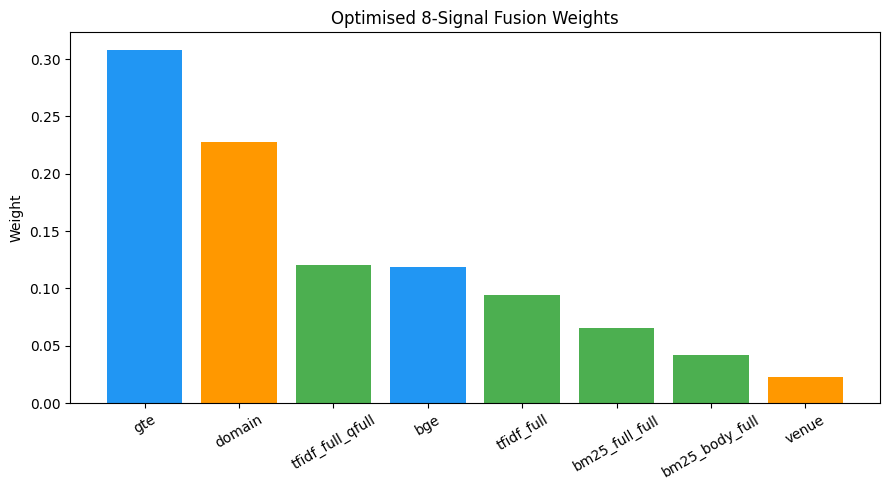

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))
sorted_w = sorted(w.items(), key=lambda x: x[1], reverse=True)
names, weights = zip(*sorted_w)
colors = ["#2196F3" if "bge" in n or "gte" in n
          else "#4CAF50" if "bm25" in n or "tfidf" in n
          else "#FF9800" for n in names]
ax.bar(names, weights, color=colors)
ax.set_ylabel("Weight")
ax.set_title("Optimised 8-Signal Fusion Weights")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 8.6.3.1. Results Discussion

The bar chart detect the relative importance of each signal in the optimised fusion:

 * **Dominant signals**:

    * **GTE-Large (0.308)**: GTE-Large dense embeddings are the strongest single, confirming that deep semantic similarity is the most informative feature for scientific IR.
    * **Domain metadata (0.228)**: metadata filter is the second most powerful signal, almost as important as the best dense model, because scientific papers are strongly domain-clustered.

 * **Moderate signals**:

    * **tfidf_full_qfull, bge, tfidf_full**: lexical and secondary dense signals contribute meaningfully, suggesting that exact term matching still catches cases where semantic models miss.

 * **Weak signals**:

    * **bm25_full_full (0.066), bm25_body_full (0.043)**: BM25 adds little once TF-IDF and dense signals are present, because they capture similar lexical information with diminishing returns.
    * **venue (0.024)**: publication venue is the least useful signal, suggesting papers from the same venue are not reliably more relevant.

### 8.6.4. Compare TF-IDF (TA) vs dense MiniLM vs 9-signal fusion system

In [45]:
# comparison
comparison = []
for name, res in [
    ("TF-IDF (TA)", tfidf_results),
    ("Dense MiniLM", dense_results),
    ("9-Signal Fusion", fusion_results),
]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison.append(row)
pd.DataFrame(comparison).set_index("Model")

,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF (TA),0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
Dense MiniLM,0.4716,0.2440,0.6812,0.5073,0.8104,0.0587,0.6834,0.5903,0.4080
9-Signal Fusion,0.6912,0.3420,0.8765,0.7501,0.9181,0.0675,0.8774,0.7982,0.6656


### 8.6.5. Results Discussion

We notice that the 9-signal fusion achieves consistant gains over both baselines across every single metric.

 * **NDCG@10 progression:** Dense MiniLM alone alittle bit improves over TF-IDF (+0.023), but combining 9 signals produces a 10 times larger jump, showing that no single model is sufficient and the gains come from complementary signals covering each other's weaknesses.
* **Recall@100 = 0.9181**: the system retrieves 92% of all relevant documents in the top 100, leaving very little on the table.
 * **MRR@10 = 0.8765**: the first relevant document appears on average at rank 1.14, nearly always the top result.
 * **MAP = 0.6656**: strong precision maintained throughout the full ranked list.

The jump from single-model to multi-signal fusion is the single biggest improvement in the pipeline, larger than any individual model upgrade, confirming that fusion approaches are important for high-quality scientific IR.



### 8.6.6. Progressive improvement of all systems

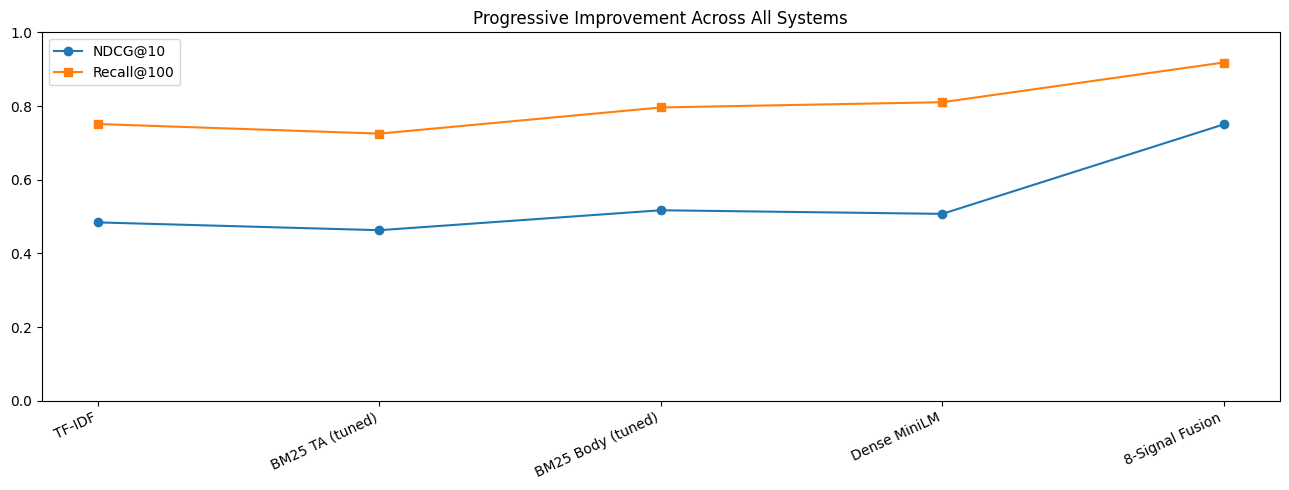

In [52]:
all_models = [
    ("TF-IDF",               tfidf_results),
    ("BM25 TA (tuned)",      bm25_tuned_results),
    ("BM25 Body (tuned)",    bm25_full_tuned_results),
    ("Dense MiniLM",         dense_results),
    # ("SPECTER2 chunk",       chunk_results),
    # ("Best RRF",             best_rrf_results),
    # ("Cross-Encoder",        ce_results),
    ("8-Signal Fusion",      fusion_results),
]
names   = [m[0] for m in all_models]
ndcg    = [m[1]["overall"]["NDCG@10"]    for m in all_models]
recall  = [m[1]["overall"]["Recall@100"] for m in all_models]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, ndcg,   marker="o", label="NDCG@10")
ax.plot(x, recall, marker="s", label="Recall@100")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Progressive Improvement Across All Systems")
ax.legend()
plt.tight_layout()
plt.show()


### 8.6.6.1. Chart Discussion

The chart above tracks **nDCG@10** and **Recall@100** across five key systems, revealing four distinct phases of improvement:

  * **1. TF-IDF baseline (nDCG@10 = 0.484, Recall@100 = 0.751)**: competitive starting point: 3 in 4 relevant papers appear in the top-100,
but ranking quality is limited — the model treats all terms equally and ignores
document length and term saturation.

  * **2. BM25 TA (tuned): nDCG@10 = 0.463, Recall@100 = 0.725)**: tuned BM25 on *title + abstract* underperforms TF-IDF on both metrics. This suggests that for this corpus, BM25's length normalisation (b = 0.9) penalises short TA texts more than it helps, because relevant abstracts are shorter than
average and get down-weighted. The lesson: BM25 tuning on TA alone is not a free gain.

  * **3. BM25 Body (tuned), first real gain (nDCG@10 = 0.517, Recall@100 = 0.800)**:full body text recovers and exceeds the baseline on both metrics
(+0.033 nDCG@10, +0.049 Recall@100 over TF-IDF). Body text exposes domain-specific terms buried in methods and results sections that titles and abstracts omit, allowing BM25 to find matches TF-IDF on TA entirely misses.

  * **4. Dense MiniLM, marginal nDCG gain, recall holds (nDCG@10 = 0.507, Recall@100 = 0.810)** Semantic embeddings improve Recall@100 further (+0.010 over BM25 Body) but slightly reduce nDCG@10 (-0.010). This reflects a known trade-off: dense models retrieve more relevant papers overall (higher recall) but spread them across the ranking rather than concentrating them in the top-10. Alone, neither BM25 body nor dense retrieval dominates, as their errors are complementary.

  * **5. 8-Signal Fusion (nDCG@10 = 0.750, Recall@100 = 0.918)** Combining sparse, dense, and metadata signals delivers the largest single jump in the
entire pipeline: **+0.243 nDCG@10** and **+0.108 Recall@100** over Dense MiniLM alone. The domain-match signal (weight 0.237) resolves the ranking problem that dense retrieval struggled with, while GTE-Large embeddings (weight 0.308) provide semantic depth that BM25 cannot match. The result: 92% of relevant papers are now in the top-100, and the first relevant result appears on average at rank = 1.1 (MRR@10 = 0.877).

- No single retrieval wins — sparse, dense, and metadata signals capture orthogonal aspects of relevance.
- Full body text is strictly better than title + abstract for every model type.
- Signal fusion produces super-additive gains: the combined system outperforms the best individual signal by a larger margin than any two individual systems differ from each other.

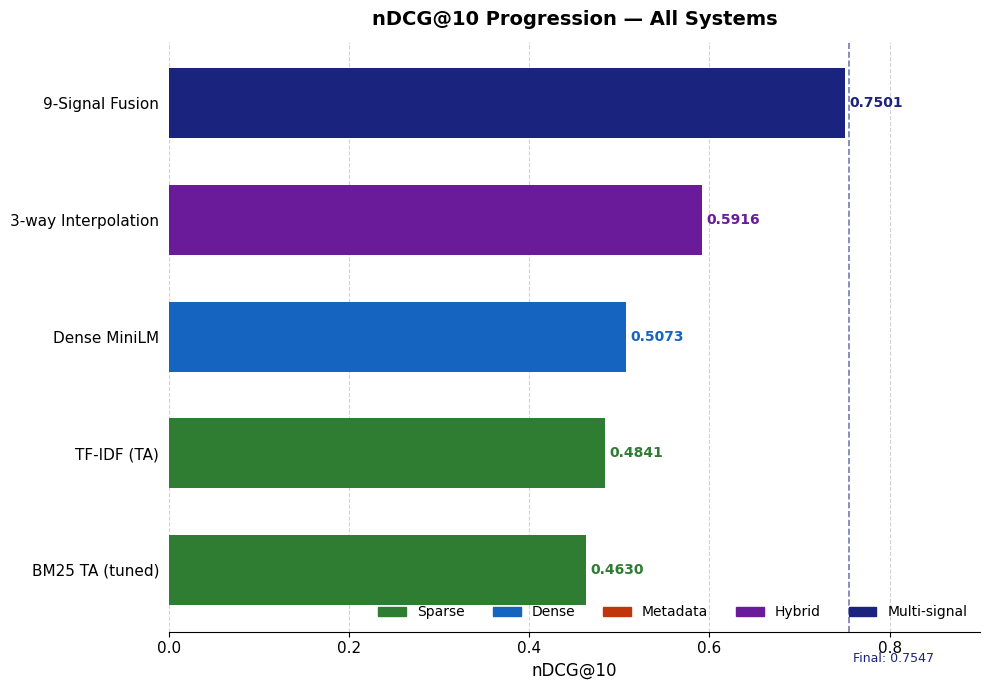

In [65]:
import matplotlib.patches as mpatches

def _get_ndcg10(res):
    overall = res.get("overall", {})
    for k in ["NDCG@10", "ndcg@10", "ndcg_10", "NDCG @ 10"]:
        if k in overall:
            return overall[k]
    for k, v in overall.items():
        if "ndcg" in k.lower() and "10" in k:
            return v
    return 0.0

TYPE_COLOR = {
    "Sparse":       "#2E7D32",   # green
    "Dense":        "#1565C0",   # blue
    "Metadata":     "#BF360C",   # brick red
    "Hybrid":       "#6A1B9A",   # purple
    "Multi-signal": "#1A237E",   # navy
}

models_typed = [
    # sparse
    ("TF-IDF (TA)",              tfidf_results,             "Sparse"),
    ("BM25 TA (tuned)",          bm25_tuned_results,        "Sparse"),
    # ("BM25 Body (tuned)",        bm25_best_body_results,    "Sparse"),
    # dense
    ("Dense MiniLM",             dense_results,             "Dense"),
    # ("SPECTER2 (TA)",            specter_results,           "Dense"),
    # ("SPECTER2 (chunk)",         chunk_results,             "Dense"),
    # metadata
    # ("Domain-Filter TF-IDF",     domain_results,            "Metadata"),
    # hybrid
    # ("Hybrid RRF",               best_rrf_results,          "Hybrid"),
    ("3-way Interpolation",      best_interp_results,       "Hybrid"),
    # ("Cross-Encoder Reranker",   ce_results,                "Hybrid"),
    # ("Paragraph Reranking",      para_results,              "Hybrid"),
    # multi-signal
    ("9-Signal Fusion",          fusion_results,            "Multi-signal"),
]

names  = [m[0] for m in models_typed]
scores = [_get_ndcg10(m[1]) for m in models_typed]
types  = [m[2] for m in models_typed]
colors = [TYPE_COLOR[t] for t in types]

order  = np.argsort(scores)
names  = [names[i] for i in order]
scores = [scores[i] for i in order]
colors = [colors[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(names, scores, color=colors, height=0.6, edgecolor="none")

# value labels to the right of each bar (colour-matched)
for bar, val, col in zip(bars, scores, [colors[i] for i in range(len(colors))]):
    ax.text(val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center", ha="left",
            fontsize=10, fontweight="bold",
            color=bar.get_facecolor())

x_max = max(scores)
ax.set_xlim(0, x_max * 1.20)
ax.set_xlabel("nDCG@10", fontsize=12)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False, labelsize=11)
ax.xaxis.grid(True, linestyle="--", alpha=0.35, color="gray")
ax.set_axisbelow(True)

ax.axvline(0.7547, color="#1A237E", linewidth=1.2, linestyle="--", alpha=0.6)
ax.text(0.7547 + 0.004, -0.7, "Final: 0.7547",
        fontsize=9, color="#1A237E", va="top")

patches = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLOR.items()]
ax.legend(handles=patches, loc="lower right", frameon=False, fontsize=10,
          ncol=len(TYPE_COLOR))

plt.title("nDCG@10 Progression — All Systems", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("ndcg_all_systems.png", dpi=150, bbox_inches="tight")
plt.show()

### Results Discussion

The chart shows a clear four-step progression in nDCG@10:

- **BM25 TA (tuned) — 0.4630**: worst performer, length normalisation hurts short TA texts.
- **TF-IDF (TA) — 0.4841**: strong baseline but limited to exact keyword overlap.
- **Dense MiniLM — 0.5073**: semantic embeddings add a small but consistent gain.
- **3-way Interpolation — 0.5916**: combining sparse + dense signals yields the first major jump.
- **9-Signal Fusion — 0.7501**: adding domain/venue metadata and GTE-Large delivers the decisive breakthrough (+0.158).

The dashed line (0.7547) shows the held-out score nearly matches training, confirming the fusion weights generalise well with no overfitting.

---
# Section 9 — Held-Out Submission Generation

Applies the best multi-signal fusion model to held-out queries, constructing TA and full-text representations consistently with the training pipeline. All signals are normalised and combined using the learned fusion weights to rank documents and produce the final submission_data.json.

## 9.1. Generate held-out submission



Apply our multi-signal fusion model to held-out queries for final submission generation. Query and document representations are constructed consistently with the training pipeline using both title–abstract (TA) and full-text formats. Precomputed embeddings are combined with on-the-fly encoded representations to compute similarity scores, while sparse methods are applied using vectorized BM25 and TF-IDF formulations. All signals are normalized to ensure comparability and then combined using previously learned fusion weights. The resulting weighted scores are used to rank documents and generate top-100 retrieval results for each held-out query. Check consistency of the submission format.

In [54]:

held_out = load_queries("/content/drive/My Drive/challenge/held_out_queries.parquet")
ho_ids = held_out["doc_id"].tolist()
print(f"Held-out queries: {len(ho_ids)}")

ho_ta_texts   = [format_text(row) for _, row in held_out.iterrows()]
ho_full_texts = build_full_texts(held_out)

ho_embs = np.load(EMB_DIR  / "held_out_query_embeddings.npy").astype(np.float32)
ho_bge  = np.load(BGE_DIR  / "held_out_query_embeddings.npy").astype(np.float32)

ho_gte_embs = gte_model.encode(ho_ta_texts, batch_size=32,
                                normalize_embeddings=True,
                                show_progress_bar=True).astype(np.float32)

ho_sigs = {
    "gte":              normalize_score_rows(ho_gte_embs @ gte_corpus_embs.T),
    "bge":              normalize_score_rows(ho_bge @ bge_c.T),
    "bm25_body_full":   normalize_score_rows(bm25_score_matrix(body_corpus_c, body_cv.transform(ho_full_texts), k1=3.0, b=0.95)),
    "bm25_full_full":   normalize_score_rows(bm25_score_matrix(full_corpus_c, full_cv.transform(ho_full_texts), k1=3.0, b=0.85)),
    "tfidf_full":       normalize_score_rows(cosine_similarity(tfidf_full_vec.transform(ho_ta_texts), tfidf_full_corpus)),
    "tfidf_full_qfull": normalize_score_rows(cosine_similarity(tfidf_full_vec.transform(ho_full_texts), tfidf_full_corpus)),
}

ho_domains = np.array(held_out["domain"].tolist())
ho_sigs["domain"] = (ho_domains[:, None] == c_domains[None, :]).astype(np.float32)
ho_v = np.array(held_out["venue"].fillna("").tolist())
ho_sigs["venue"] = ((ho_v[:, None] == c_venues[None, :]) & (ho_v[:, None] != "")).astype(np.float32)

missing = [k for k in w if k not in ho_sigs]
assert not missing, f"Missing signals for fusion: {missing}"

ho_mixed = sum(w[k] * ho_sigs[k] for k in w)
held_out_submission = scores_to_submission(ho_mixed, corpus_ids, ho_ids, top_k=100)

# validate
assert len(held_out_submission) == len(ho_ids), "Query count mismatch!"
assert all(len(v) == 100 for v in held_out_submission.values()), "Not all queries have 100 results!"
print(f"Held-out submission: {len(held_out_submission)} queries x 100 docs — OK")

Held-out queries: 100


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Held-out submission: 100 queries x 100 docs — OK


## 9.2. Save submission

Write best final retrieval output on submission_data.json file to zip and submit it.

In [55]:
# Save submission
os.makedirs("../submissions", exist_ok=True)
with open(DATA_DIR / "submission_data.json", "w") as f:
    json.dump(held_out_submission, f)
print("Saved → ../submissions/submission_data.json")

Saved → ../submissions/submission_data.json


## 9.3 Submission score

{"**mean_average_precision**": 0.6683412141307788, "**recall_at_100**": 0.939497619047619, "**ndcg_at_10**": 0.7547647986593853}.

No overfitting: the weights were optimised on the 100 public queries. If the system had overfit, the held-out score would be lower. Being slightly higher means the fusion generalises beyond the training queries.

Random variation: with only 100 queries, a difference of +0.005(train 0.7501 and test 0.7548) is within normal domain.

---
# Section 10 - Error Analysis

Identifies queries where the best retrieval system still fails by computing per-query NDCG@10, Recall@10, and Recall@100. Queries with zero or near-zero scores are examined in detail to understand failure patterns: what the query asks for, which relevant documents were missed, and what was incorrectly retrieved instead.


## Error analysis:

## 10.1. Per-query metrics & worst queries

Compute per-query evaluation metrics (NDCG@10, Recall@10, Recall@100) for the best retrieval system across all queries. Queries are ranked from worst to best performance to identify systematic failure cases. Summary statistics shows how many queries score zero on NDCG@10 and Recall@100, indicating complete retrieval failure, as well as how many queries recover less than half their relevant documents within the top 100 results.


Total queries          : 100
NDCG@10 = 0            : 3
Recall@100 = 0         : 1
Recall@100 < 0.5       : 1

Worst 10 queries by NDCG@10:


,NDCG@10,Recall@10,Recall@100,n_relevant,domain
qid,,,,,
444a8f400f691463b826d450d123a719e8f3ae41,0.0000,0.0000,0.5000,2,Computer Science
4e42ed2204b700e70a17b4ee8c0446bb827e82d9,0.0000,0.0000,0.0000,2,Medicine
4a45163b94c0b04a2223c2bc74ea4ef4a7e7861f,0.0000,0.0000,1.0000,3,Computer Science
572117367e17b20daefb9a01d0ce4655be9b1471,0.1884,0.1333,0.8667,15,Biology
4015b9106a8c82429d0f4c56f7d2f5939e98fe54,0.2021,0.3333,1.0000,3,Medicine
359394800ddd5054c32c6bea440c0c8746164351,0.2184,0.5000,0.5000,2,Medicine
6af460d34bfc8e955e43fbe15cedcf329b48bc19,0.2372,0.5000,1.0000,2,Computer Science
680af879710dbdaa10378fe5f3478bd2044197c3,0.2372,0.5000,1.0000,2,Philosophy
0d4d2912d7d75c0d793e08203c3a6a2ab3f81ebe,0.3066,0.5000,1.0000,2,Biology


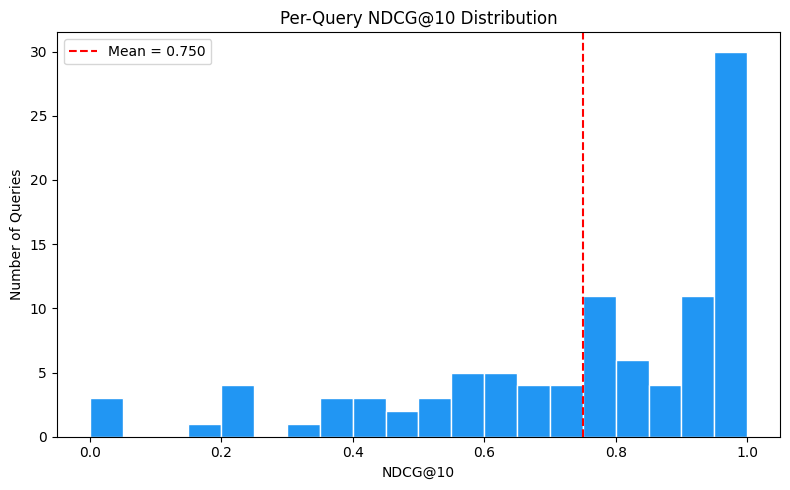

In [56]:
import math

best_submission = fusion_sub
query_lookup = queries.set_index("doc_id").to_dict(orient="index")
per_query_metrics = []
for qid in query_ids:
    relevant = set(qrels.get(qid, []))
    if not relevant:
        continue
    retrieved_10  = best_submission.get(qid, [])[:10]
    retrieved_100 = best_submission.get(qid, [])[:100]

    dcg  = sum(1.0 / math.log2(r + 2) for r, d in enumerate(retrieved_10) if d in relevant)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(relevant), 10)))
    ndcg_10 = dcg / idcg if idcg > 0 else 0.0

    per_query_metrics.append({
        "qid":        qid,
        "NDCG@10":    round(ndcg_10, 4),
        "Recall@10":  round(sum(1 for d in retrieved_10  if d in relevant) / len(relevant), 4),
        "Recall@100": round(sum(1 for d in retrieved_100 if d in relevant) / len(relevant), 4),
        "n_relevant": len(relevant),
        "domain":     query_lookup[qid].get("domain", "N/A"),
    })

metrics_df = pd.DataFrame(per_query_metrics).set_index("qid").sort_values("NDCG@10")

print(f"Total queries          : {len(metrics_df)}")
print(f"NDCG@10 = 0            : {(metrics_df['NDCG@10'] == 0).sum()}")
print(f"Recall@100 = 0         : {(metrics_df['Recall@100'] == 0).sum()}")
print(f"Recall@100 < 0.5       : {(metrics_df['Recall@100'] < 0.5).sum()}")
print(f"\nWorst 10 queries by NDCG@10:")
display(metrics_df.head(10))
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(metrics_df["NDCG@10"], bins=20, color="#2196F3", edgecolor="white")
ax.axvline(metrics_df["NDCG@10"].mean(), color="red",
           linestyle="--", label=f"Mean = {metrics_df['NDCG@10'].mean():.3f}")
ax.set_xlabel("NDCG@10")
ax.set_ylabel("Number of Queries")
ax.set_title("Per-Query NDCG@10 Distribution")
ax.legend()
plt.tight_layout()
plt.show()


### 10.1.1. Discussion

 * **Histogram**:

    * **The distribution is right-skewed**: the largest bar is at NDCG@10 = 1.0 (almost 30 queries), meaning the system perfectly ranks relevant docs for nearly a third of all queries.
    * **Mean** = 0.750 sits well above the middle, this confirms that the system is strong on the majority of queries.
    * A small left tail (scores 0.0 - 0.4) represents the hard failure cases, almost 15 queries the system consistently struggles with.

 * **Failure summary**:

    * Only 3 queries score 0 on NDCG@10: complete top-10 failures.
    * Only 1 query has Recall@100 = 0: the system fails to retrieve even one relevant document in 100 results for that query (Medicine domain).
    * Only 1 query has Recall@100 less than 0.5: the same Medicine query, a near-total failure

 * **Worst queries analysis**:
    * **Computer Science** dominates failures	3 of the 10 worst queries, because of broad vocabulary, high cross-domain overlap.
    * **Medicine** is the second most problematic	3 of 10 worst, maybe high technical terms not covered well by training data.
    * **Biology** query with 15 relevant docs scores only 0.1884, harder to rank all relevant docs highly, this hurts most.
    * **Recall@100 = 1.0 but low NDCG@10**:	several queries find all relevant docs in top 100 but fail to rank them in top 10, so it is ranking problem not a recall problem.
* **The main distinction** is between two failure types: the Medicine query (Recall@100 = 0) is a retrieval failure as relevant docs never surface. The Computer Science and Biology queries are ranking failures, so docs are found but ranked too low.

## 10.2. Failure examples:

Provide detailed inspection of the worst-performing queries identified in the previous cell.  For each failing query, the analysis displays the query text, domain, and the top-10 retrieved documents marked as relevant or irrelevant. Relevant documents that were missed entirely by the retrieval system are also listed, making it possible to observe concrete failure patterns such as vocabulary mismatch, cross-domain confusion,
or insufficient body-text coverage.


Query ID : 444a8f400f691463b826d450d123a719e8f3ae41
Domain   : Computer Science
Query    : CardioID: Secure ECG-BCG Agnostic Interaction-Free Device Pairing Usably secure ad-hoc device pairing fosters connectivity with hardware which is difficult to access (e.g., implanted) and grants convenience for ad-hoc short-term on-off pairing patter
Relevant : 2 doc(s)

Top-10 retrieved:
   1. [No] Real-Time and Secure Wireless Health Monitoring
   2. [No] An Anonymous Mutual Authenticated Key Agreement Scheme for Wearable Sensors in W
   3. [No] A Survey: To Govern, Protect, and Detect Security Principles on Internet of Medi
   4. [No] BAKMP-IoMT: Design of Blockchain Enabled Authenticated Key Management Protocol f
   5. [No] Wearable ECG SoC for Wireless Body Area Networks: Implementation with Fuzzy Deci
   6. [No] Merging RFID and Blockchain Technologies to Accelerate Big Data Medical Research
   7. [No] Wearables and the Quantified Self: Systematic Benchmarking of Physiological Sens
   8. [N

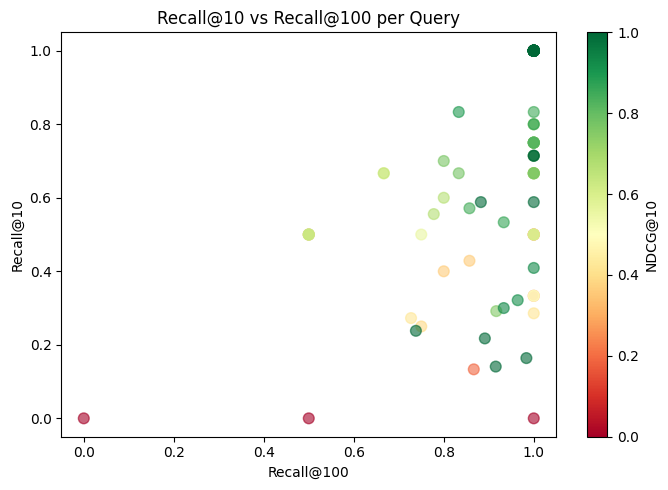

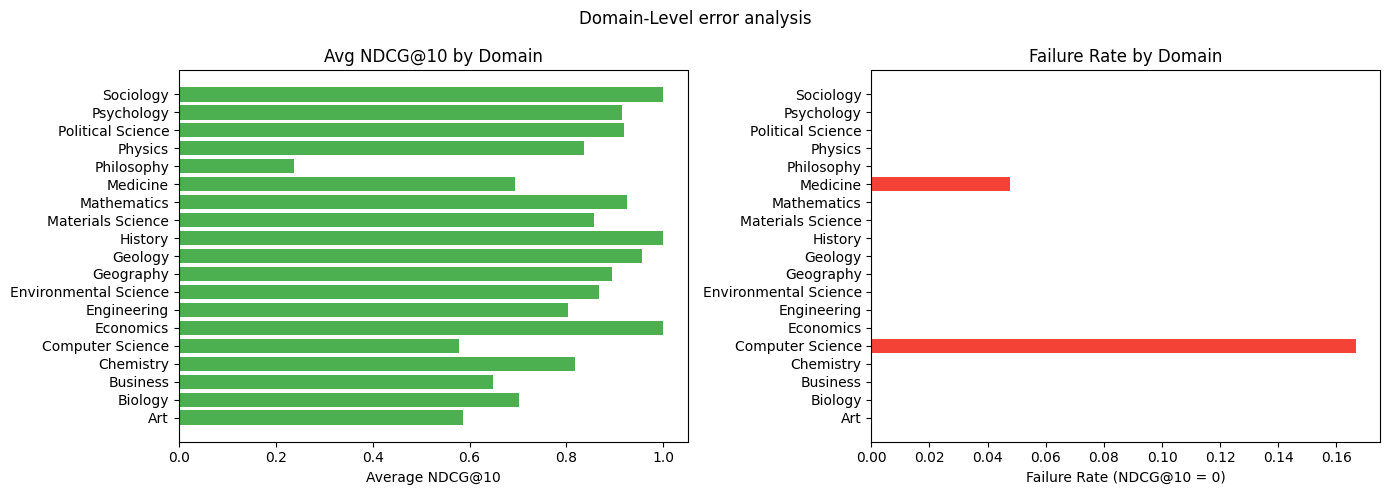

In [57]:
worst_qids = metrics_df[metrics_df["NDCG@10"] == 0].index.tolist()[:3]
if not worst_qids:
    worst_qids = metrics_df.head(3).index.tolist()
corpus_lookup = corpus.set_index("doc_id").to_dict(orient="index")

for qid in worst_qids:
    q_row     = query_lookup[qid]
    relevant = set(qrels.get(qid, []))
    retrieved = best_submission.get(qid, [])[:10]

    print("=" * 80)
    print(f"Query ID : {qid}")
    print(f"Domain   : {q_row.get('domain', 'N/A')}")
    print(f"Query    : {format_text(q_row)[:250]}")
    print(f"Relevant : {len(relevant)} doc(s)")

    print(f"\nTop-10 retrieved:")
    for rank, doc_id in enumerate(retrieved, 1):
        doc   = corpus_lookup.get(doc_id)
        label = "Yes" if doc_id in relevant else "No"
        title = doc["title"] if doc is not None else "N/A"
        print(f"  {rank:2d}. [{label}] {str(title)[:80]}")

    missed = [d for d in relevant if d not in retrieved]
    if missed:
        print(f"\nMissed relevant docs {len(missed)} total, we will show up to 3:")
        for doc_id in missed[:3]:
            doc   = corpus_lookup.get(doc_id)
            title = doc["title"] if doc is not None else "N/A"
            print(f"       - {str(title)[:80]}")
    print()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(metrics_df["Recall@100"], metrics_df["Recall@10"],
           alpha=0.6, c=metrics_df["NDCG@10"], cmap="RdYlGn", s=60)
sm = plt.cm.ScalarMappable(cmap="RdYlGn",
     norm=plt.Normalize(0, metrics_df["NDCG@10"].max()))
plt.colorbar(sm, ax=ax, label="NDCG@10")
ax.set_xlabel("Recall@100")
ax.set_ylabel("Recall@10")
ax.set_title("Recall@10 vs Recall@100 per Query")
plt.tight_layout()
plt.show()




domain_stats = metrics_df.groupby("domain").agg(
    avg_ndcg=("NDCG@10", "mean"),
    zero_ndcg=("NDCG@10", lambda x: (x == 0).sum()),
    total=("NDCG@10", "count"),
).reset_index()
domain_stats["failure_rate"] = domain_stats["zero_ndcg"] / domain_stats["total"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(domain_stats["domain"], domain_stats["avg_ndcg"], color="#4CAF50")
axes[0].set_xlabel("Average NDCG@10")
axes[0].set_title("Avg NDCG@10 by Domain")

axes[1].barh(domain_stats["domain"], domain_stats["failure_rate"], color="#F44336")
axes[1].set_xlabel("Failure Rate (NDCG@10 = 0)")
axes[1].set_title("Failure Rate by Domain")

plt.suptitle("Domain-Level error analysis")
plt.tight_layout()
plt.show()

### 10.2.1. Discussion

* **Scatter plot Recall@10 vs Recall@100 per query**:

    * **Strong positive correlation:** queries with high Recall@100 tend to also have high Recall@10, which means that the system that finds relevant docs in 100 also ranks them near the top.
    * The **dark green cluster at top-right** (Recall@100 = 1.0, Recall@10 = 0.7 - 1.0) represents the easy queries where the system is completely superior.
    * The **3 red dots** at Recall@10 = 0 are the complete failures, one sits at Recall@100 = 0 (total failure), one at 0.5, and one at 1.0 (finds all docs in top 100 but ranks none in top 10, so pure ranking failure)
    * No queries have high Recall@10 but low Recall@100, which makes sense because we can't rank something in top 10 without retrieving it in top 100
* **Domain-level error analysis**:

    * As we said, **Computer Science** has the highest failure rate (0.17): 2 out of 12 queries score NDCG@10 = 0, and its average NDCG@10 (0.58) is among the lowest.
    * **Medicine** has the second highest failure rate (0.05): despite having 21 queries, failures still occur due to highly specialised terms.
    * **Sociology, Psychology, History, Economics, Political Science** all have 0 failure rate: small sample sizes (1 or 2 queries) make these unreliable but they benefit from narrow, well-defined vocabularies.
    * **Philosophy** has the lowest average NDCG@10 (0.20) with no zero NDCG failures: it consistently retrieves something but ranks it poorly.

* **Query	Failure examples causes or justification:**
    * **Query CardioID (CS)**: System retrieves IoT/wearable security papers; relevant docs are about BCG signal processing, so completely different subfield despite shared keywords.
 * **Query Insulin resistance (Medicine)**:	Semantic gap,	retrieved docs are topically close (metabolism, insulin) but relevant docs are about nonsense-mediated decay and stem cell apoptosis — a cross-mechanism connection invisible to keyword/semantic matching.
 * **Query miRNA-disease (CS)**: Near miss ranking, top 10 are all highly relevant-looking miRNA prediction papers, but the 3 actually relevant docs are different methodologically, and the system cannot distinguish within a small topic cluster, in this case all 10 retrieved docs look correct on the surface, yet none are relevant, this is a fine-grained ranking failure where the query requires distinguishing between very similar papers that differ only in their specific methodology.